In [ ]:
from google.colab import drive; drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
=============================================================================
BLOK 1: INISIALISASI & KONFIGURASI GLOBAL
Metodologi: Klasifikasi Obat (NSAID vs Antibiotik) menggunakan ML Klasik
=============================================================================
"""

import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── KONFIGURASI PATH & DATASET ──
# PASTIKAN PATH INI SESUAI DENGAN GOOGLE DRIVE ANDA
DATASET_ROOT = Path("/content/drive/MyDrive/DatasetLASA")
DIR_LABEL_MAP = {
    "pereda_nyeri":         0,
    "pereda_nyeri_bungkus": 0,
    "antibiotik":           1,
    "antibiotik_Bungkus":   1,
}
CLASS_NAMES = ["NSAID (Pereda Nyeri)", "Antibiotik"]

# ── KONFIGURASI FITUR & AUGMENTASI ──
HSV_BINS = (9, 4, 4)           # 144 bins untuk efisiensi komputasi
SHAPE_DIM = 10                 # Aspect ratio, circularity, eccentricity, 7 Hu Moments
IMG_SIZE  = (200, 200)         # Normalisasi dimensi citra
ROTATION_ANGLES = [0, 45, 90, 135, 180] # 5 Templates Augmentasi Rotasi

print("Blok 1 Selesai: Lingkungan kerja berhasil diinisialisasi.")

Blok 1 Selesai: Lingkungan kerja berhasil diinisialisasi.


In [ ]:
"""
=============================================================================
BLOK 2: AKUISISI DATA & EKSTRAKSI FITUR (BEBAS DATA LEAK)
Sesuai metodologi: Penggabungan Fitur Warna (HSV) dan Bentuk (Shape)
=============================================================================
"""
print("Memulai ekstraksi fitur... (Proses ini membutuhkan waktu beberapa detik)")

# 1. Fungsi Ekstraksi Fitur
def extract_hsv_histogram(img_hsv: np.ndarray) -> np.ndarray:
    hist = cv2.calcHist([img_hsv], [0, 1, 2], None, list(HSV_BINS), [0, 180, 0, 256, 0, 256])
    hist = hist.flatten().astype(np.float32)
    if hist.sum() > 0: hist /= hist.sum() # L1-Normalization
    return hist

def extract_shape_features(img_gray: np.ndarray) -> np.ndarray:
    features = np.zeros(SHAPE_DIM, dtype=np.float32)
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        moments = cv2.moments(c)
        area, perimeter = cv2.contourArea(c), cv2.arcLength(c, True)
        x, y, w, h = cv2.boundingRect(c)

        features[0] = w / h if h > 0 else 1.0 # Aspect Ratio
        if perimeter > 0: features[1] = (4.0 * np.pi * area) / (perimeter ** 2) # Circularity
        if len(c) >= 5:
            (_, _), (minor, major), _ = cv2.fitEllipse(c)
            features[2] = minor / major if major > 0 else 1.0 # Eccentricity
        else:
            features[2] = 1.0

        hu = cv2.HuMoments(moments).flatten()
        for i, val in enumerate(hu):
            features[3 + i] = -np.sign(val) * np.log10(abs(val) + 1e-10) if val != 0 else 0.0
    return features

# 2. Baca RAW Images terlebih dahulu (TANPA AUGMENTASI)
X_raw, y_raw = [], []
for subdir, label in DIR_LABEL_MAP.items():
    folder = DATASET_ROOT / subdir
    if not folder.exists(): continue

    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]: continue
        img_bgr = cv2.imread(str(f))
        if img_bgr is None: continue
        img_bgr = cv2.resize(img_bgr, IMG_SIZE)

        X_raw.append(img_bgr)
        y_raw.append(label)

print(f"Total RAW Images ditemukan: {len(X_raw)}")

# 3. MENCEGAH DATA LEAK: Lakukan Stratified Split SEBELUM Augmentasi
X_train_raw, X_test_raw, y_train_base, y_test_base = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)

# 4. Augmentasi & Ekstraksi HANYA pada Data Training
X_train_features, y_train_features = [], []
for i, img in enumerate(X_train_raw):
    for angle in ROTATION_ANGLES:
        cx, cy = IMG_SIZE[0]//2, IMG_SIZE[1]//2
        M = cv2.getRotationMatrix2D((cx, cy), -angle, 1.0)
        img_rot = cv2.warpAffine(img, M, IMG_SIZE)

        img_hsv = cv2.cvtColor(img_rot, cv2.COLOR_BGR2HSV)
        img_gray = cv2.cvtColor(img_rot, cv2.COLOR_BGR2GRAY)

        feat_color = extract_hsv_histogram(img_hsv)
        feat_shape = extract_shape_features(img_gray)

        X_train_features.append(np.concatenate([feat_color, feat_shape]))
        y_train_features.append(y_train_base[i])

# 5. Ekstraksi Data Testing (MURNI, TANPA ROTASI / AUGMENTASI)
X_test_features, y_test_features = [], []
for i, img in enumerate(X_test_raw):
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    feat_color = extract_hsv_histogram(img_hsv)
    feat_shape = extract_shape_features(img_gray)

    X_test_features.append(np.concatenate([feat_color, feat_shape]))
    y_test_features.append(y_test_base[i])

# Konversi ke Numpy Array
X_train_full = np.array(X_train_features, dtype=np.float32)
y_train_full = np.array(y_train_features, dtype=np.int32)
X_test_full = np.array(X_test_features, dtype=np.float32)
y_test_full = np.array(y_test_features, dtype=np.int32)

print(f"Blok 2 Selesai: Matriks Train: {X_train_full.shape}, Matriks Test: {X_test_full.shape}")


Memulai ekstraksi fitur... (Proses ini membutuhkan waktu beberapa detik)
Total RAW Images ditemukan: 133
Blok 2 Selesai: Matriks Train: (530, 154), Matriks Test: (27, 154)


In [ ]:
"""
=============================================================================
BLOK 3: EKSPERIMEN 3 MODEL x 3 ITERASI (TRAINING & EVALUASI)
=============================================================================
"""
seeds = [42, 123, 456]

model_configs = {
    "Random Forest": lambda s: RandomForestClassifier(n_estimators=100, random_state=s, class_weight="balanced", n_jobs=-1),
    "KNN":           lambda s: KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1),
    "SVM":           lambda s: SVC(kernel="rbf", C=1.0, probability=True, random_state=s, class_weight="balanced")
}

hasil_eksperimen = []
best_accuracy = 0
best_model_info = {}

print("\nMemulai proses pelatihan (3 Algoritma x 3 Iterasi)...")

for model_name, model_fn in model_configs.items():
    print(f"➜ Melatih model: {model_name}")
    for i, seed in enumerate(seeds):

        # A. Scaling & PCA (Fit hanya pada Train Set)
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train_full)
        X_test_scaled  = scaler.transform(X_test_full)

        pca = PCA(n_components=0.95, random_state=seed)
        X_train_pca = pca.fit_transform(X_train_scaled)
        X_test_pca  = pca.transform(X_test_scaled)

        # B. SMOTE pada Training Set
        smote_k = min(5, np.bincount(y_train_full).min() - 1)
        if smote_k > 0:
            smote = SMOTE(k_neighbors=smote_k, random_state=seed)
            X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train_full)
        else:
            X_train_final, y_train_final = X_train_pca, y_train_full

        # C. Training Model
        clf = model_fn(seed)
        t0 = time.time()
        clf.fit(X_train_final, y_train_final)
        waktu_latih = time.time() - t0

        # D. Prediksi & Evaluasi pada MURNI Test Set
        y_pred = clf.predict(X_test_pca)
        y_prob = clf.predict_proba(X_test_pca)

        acc  = accuracy_score(y_test_full, y_pred)
        prec = precision_score(y_test_full, y_pred, zero_division=0)
        rec  = recall_score(y_test_full, y_pred, zero_division=0)
        f1   = f1_score(y_test_full, y_pred, zero_division=0)
        loss = log_loss(y_test_full, y_prob)

        hasil_eksperimen.append({
            "Model": model_name,
            "Iterasi": i + 1,
            "Seed": seed,
            "Akurasi": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "Log Loss": loss,
            "Waktu (s)": waktu_latih
        })

        print(f"   - Iterasi {i+1} (Seed {seed}) | Akurasi Real: {acc*100:.2f}% | Loss: {loss:.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_model_info = {
                "Model": model_name,
                "Iterasi": i + 1,
                "Seed": seed,
                "y_test": y_test_full,
                "y_pred": y_pred,
                "Akurasi": acc,
                "Log Loss": loss
            }

df_hasil = pd.DataFrame(hasil_eksperimen)
print("\nBlok 3 Selesai: Evaluasi model tanpa data leak selesai.")


Memulai proses pelatihan (3 Algoritma x 3 Iterasi)...
➜ Melatih model: Random Forest
   - Iterasi 1 (Seed 42) | Akurasi Real: 59.26% | Loss: 0.6672
   - Iterasi 2 (Seed 123) | Akurasi Real: 70.37% | Loss: 0.6135
   - Iterasi 3 (Seed 456) | Akurasi Real: 70.37% | Loss: 0.6352
➜ Melatih model: KNN
   - Iterasi 1 (Seed 42) | Akurasi Real: 59.26% | Loss: 4.4875
   - Iterasi 2 (Seed 123) | Akurasi Real: 59.26% | Loss: 4.4875
   - Iterasi 3 (Seed 456) | Akurasi Real: 59.26% | Loss: 4.4875
➜ Melatih model: SVM
   - Iterasi 1 (Seed 42) | Akurasi Real: 70.37% | Loss: 0.6947
   - Iterasi 2 (Seed 123) | Akurasi Real: 70.37% | Loss: 0.6936
   - Iterasi 3 (Seed 456) | Akurasi Real: 70.37% | Loss: 0.6713

Blok 3 Selesai: Evaluasi model tanpa data leak selesai.



=== TABEL HASIL SELURUH EKSPERIMEN (TRUE ACCURACY) ===
| Model         |   Iterasi |   Seed | Akurasi   | Precision   | Recall   | F1-Score   |   Log Loss |   Waktu (s) |
|:--------------|----------:|-------:|:----------|:------------|:---------|:-----------|-----------:|------------:|
| Random Forest |         1 |     42 | 59.26%    | 57.14%      | 61.54%   | 59.26%     |     0.6672 | 0.418087    |
| Random Forest |         2 |    123 | 70.37%    | 66.67%      | 76.92%   | 71.43%     |     0.6135 | 0.596735    |
| Random Forest |         3 |    456 | 70.37%    | 69.23%      | 69.23%   | 69.23%     |     0.6352 | 0.760378    |
| KNN           |         1 |     42 | 59.26%    | 57.14%      | 61.54%   | 59.26%     |     4.4875 | 0.000621796 |
| KNN           |         2 |    123 | 59.26%    | 57.14%      | 61.54%   | 59.26%     |     4.4875 | 0.000731945 |
| KNN           |         3 |    456 | 59.26%    | 57.14%      | 61.54%   | 59.26%     |     4.4875 | 0.000864267 |
| SVM           

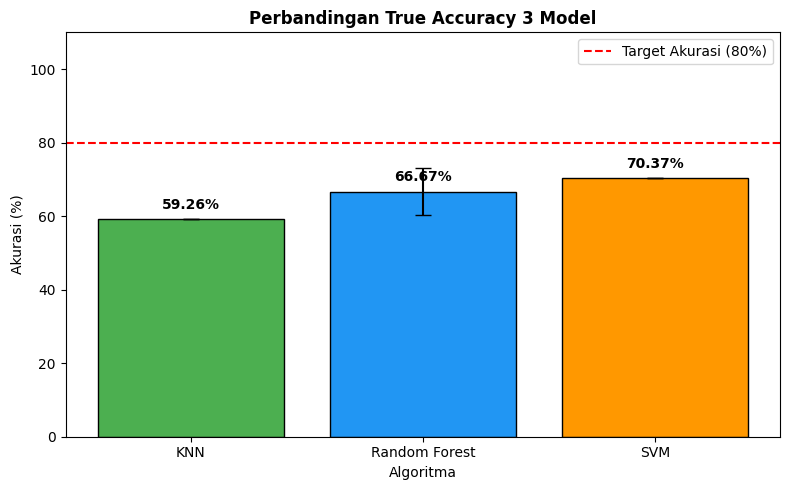


=== CONFUSION MATRIX MODEL TERBAIK ===


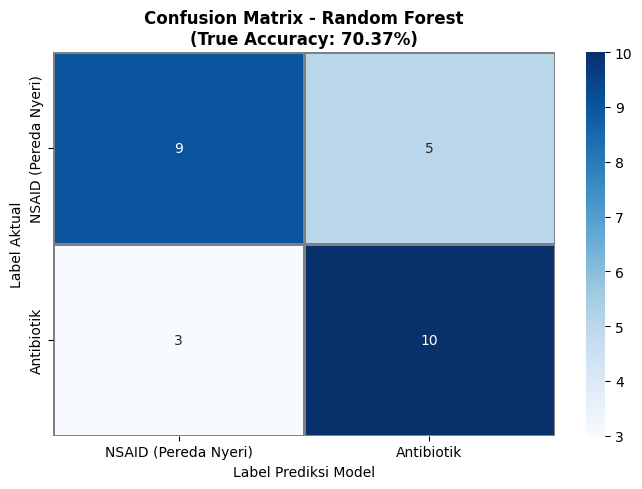

In [ ]:
"""
=============================================================================
BLOK 4: VISUALISASI DAN ANALISIS HASIL
=============================================================================
"""
print("\n=== TABEL HASIL SELURUH EKSPERIMEN (TRUE ACCURACY) ===")
df_tampil = df_hasil.copy()
for col in ["Akurasi", "Precision", "Recall", "F1-Score"]:
    df_tampil[col] = (df_tampil[col] * 100).round(2).astype(str) + "%"
df_tampil["Log Loss"] = df_tampil["Log Loss"].round(4)
print(df_tampil.to_markdown(index=False))

df_mean = df_hasil.groupby("Model").agg({
    "Akurasi": ["mean", "std"],
    "Log Loss": "mean"
}).reset_index()
df_mean.columns = ["Model", "Mean Akurasi", "Std Akurasi", "Mean Log Loss"]

print("\n\n=== RATA-RATA KINERJA PER MODEL ===")
df_mean_tampil = df_mean.copy()
df_mean_tampil["Mean Akurasi"] = (df_mean_tampil["Mean Akurasi"] * 100).round(2).astype(str) + "%"
df_mean_tampil["Mean Log Loss"] = df_mean_tampil["Mean Log Loss"].round(4)
print(df_mean_tampil.to_markdown(index=False))

# Bar Chart
plt.figure(figsize=(8, 5))
warna = ['#4CAF50', '#2196F3', '#FF9800']
bars = plt.bar(df_mean["Model"], df_mean["Mean Akurasi"] * 100, yerr=df_mean["Std Akurasi"] * 100,
               color=warna, edgecolor='black', capsize=6)

plt.axhline(80, color='red', linestyle='--', label='Target Akurasi (80%)')
plt.ylim(0, 110)
plt.title("Perbandingan True Accuracy 3 Model", fontsize=12, fontweight='bold')
plt.ylabel("Akurasi (%)", fontsize=10)
plt.xlabel("Algoritma", fontsize=10)
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrix
print("\n=== CONFUSION MATRIX MODEL TERBAIK ===")
cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='gray')
plt.title(f'Confusion Matrix - {best_model_info["Model"]}\n(True Accuracy: {best_model_info["Akurasi"]*100:.2f}%)',
          fontsize=12, fontweight='bold')
plt.ylabel('Label Aktual', fontsize=10)
plt.xlabel('Label Prediksi Model', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import copy

# =====================================================================
# 1. ADVANCED SYNTHETIC DATA: PREPROCESSING & AUGMENTATION
# =====================================================================

def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is None: return None

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)

        # Create an exact mask of the pill
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask, [c], -1, 255, -1)

        pill_roi = image[y:y+h, x:x+w]
        mask_roi = mask[y:y+h, x:x+w]

        # ADVANCED SYNTHESIS: Generate harsh, random noise background
        synthetic_bg = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)

        # Paste the pill perfectly onto the noise
        mask_roi_3ch = cv2.cvtColor(mask_roi, cv2.COLOR_GRAY2BGR)
        pill_extracted = np.where(mask_roi_3ch == 255, pill_roi, synthetic_bg)

        roi_resized = cv2.resize(pill_extracted, (256, 256), interpolation=cv2.INTER_AREA)
    else:
        roi_resized = cv2.resize(image, (256, 256), interpolation=cv2.INTER_AREA)

    return cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB)

# Heavy augmentation simulating paper's color changes + Random Erasing
augmentation_pipeline = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=15, scale=(0.8, 1.2)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_pipeline = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PillFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        # Force binary classification mapping
        self.label_map = {
            "pereda_nyeri": 0,
            "pereda_nyeri_bungkus": 0,
            "antibiotik": 1,
            "antibiotik_Bungkus": 1,
        }

        self.classes = ["NSAID (Pereda Nyeri)", "Antibiotik"]

        for folder_name in os.listdir(root_dir):
            cls_dir = os.path.join(root_dir, folder_name)
            if not os.path.isdir(cls_dir): continue

            # Map the folder to the binary label
            if folder_name in self.label_map:
                mapped_label = self.label_map[folder_name]

                for img_name in os.listdir(cls_dir):
                    img_path = os.path.join(cls_dir, img_name)
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(img_path)
                        self.labels.append(mapped_label)

        self.targets = self.labels

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        processed_img = preprocess_image(img_path)

        if processed_img is None:
            processed_img = np.zeros((256, 256, 3), dtype=np.uint8)

        if self.transform: tensor_img = self.transform(processed_img)
        return tensor_img, label

# =====================================================================
# 2. CUTMIX HELPER & METRIC LOSS
# =====================================================================

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

class CenterLoss(nn.Module):
    def __init__(self, num_classes, feat_dim, device):
        super(CenterLoss, self).__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.device = device
        self.centers = nn.Parameter(torch.randn(self.num_classes, self.feat_dim).to(device))

    def forward(self, x, labels):
        batch_size = x.size(0)
        centers_batch = self.centers.index_select(0, labels)
        loss = (x - centers_batch).pow(2).sum() / 2.0 / batch_size
        return loss

# =====================================================================
# 3. MODEL ARCHITECTURE (EfficientNet-B2)
# =====================================================================

class EfficientNetPillClassifier(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetPillClassifier, self).__init__()
        self.base_model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)

        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Identity()
        self.fc_layer = nn.Linear(in_features, num_classes)

    def forward(self, x):
        embeddings = self.base_model(x)
        logits = self.fc_layer(embeddings)
        return logits, embeddings


# =====================================================================
# COLAB EXECUTION & EXACT TRAINING LOOP
# =====================================================================
if __name__ == "__main__":

    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    DATASET_PATH = '/content/drive/MyDrive/DatasetLASA (1)'

    base_dataset = PillFolderDataset(root_dir=DATASET_PATH, transform=None)
    num_classes = len(base_dataset.classes)
    total_size = len(base_dataset)

    if total_size == 0:
        print("ERROR: Found 0 images. Please check your dataset path.")
    else:
        train_size = int(0.6 * total_size)
        val_size = int(0.2 * total_size)
        test_size = total_size - train_size - val_size

        generator = torch.Generator().manual_seed(42)
        indices = torch.randperm(total_size, generator=generator).tolist()

        train_dataset_base = copy.deepcopy(base_dataset)
        train_dataset_base.transform = augmentation_pipeline
        train_dataset = Subset(train_dataset_base, indices[:train_size])

        val_dataset_base = copy.deepcopy(base_dataset)
        val_dataset_base.transform = val_test_pipeline
        val_dataset = Subset(val_dataset_base, indices[train_size:train_size + val_size])

        BATCH_SIZE = 16

        train_targets = [base_dataset.targets[i] for i in indices[:train_size]]
        class_counts = np.bincount(train_targets, minlength=num_classes)
        weights = 1. / (class_counts + 1e-5)
        sampler = WeightedRandomSampler(weights=weights[train_targets], num_samples=len(train_targets), replacement=True)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = EfficientNetPillClassifier(num_classes=num_classes).to(device)

        criterion_ce = nn.CrossEntropyLoss()
        center_loss = CenterLoss(num_classes=num_classes, feat_dim=1408, device=device)

        # Stabilized loss weight so it doesn't fight classification
        loss_weight = 0.05

        optimizer = optim.Adam([
            {'params': model.parameters(), 'lr': 1e-4},
            {'params': center_loss.parameters(), 'lr': 1e-2}
        ], weight_decay=1e-4)

        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

        EPOCHS = 100
        patience = 20
        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(model.state_dict())

        print(f"\nStarting Few-Shot Training on {device} with EfficientNet-B2, Advanced Synthesis, and Center Loss...")

        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            correct, total = 0, 0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                # ADVANCED SYNTHESIS: 33% MixUp, 33% CutMix, 33% Standard
                r = np.random.rand(1)
                if r < 0.33:
                    # Apply MixUp
                    lam = np.random.beta(1.0, 1.0)
                    rand_index = torch.randperm(inputs.size()[0]).to(device)
                    target_a, target_b = labels, labels[rand_index]
                    inputs = lam * inputs + (1 - lam) * inputs[rand_index, :]
                elif r < 0.66:
                    # Apply CutMix
                    lam = np.random.beta(1.0, 1.0)
                    rand_index = torch.randperm(inputs.size()[0]).to(device)
                    target_a, target_b = labels, labels[rand_index]
                    bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
                    inputs[:, :, bbx1:bbx2, bby1:bby2] = inputs[rand_index, :, bbx1:bbx2, bby1:bby2]
                    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size()[-1] * inputs.size()[-2]))
                else:
                    # Standard Training
                    lam = 1.0
                    target_a, target_b = labels, labels

                logits, embeddings = model(inputs)

                loss_ce = lam * criterion_ce(logits, target_a) + (1 - lam) * criterion_ce(logits, target_b)
                loss_center = lam * center_loss(embeddings, target_a) + (1 - lam) * center_loss(embeddings, target_b)
                loss = loss_ce + (loss_weight * loss_center)

                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = torch.max(logits.data, 1)
                total += labels.size(0)

                # Accuracy tracks the dominant label
                correct += (predicted == (target_a if lam > 0.5 else target_b)).sum().item()

            train_loss = running_loss / len(train_loader)
            train_acc = 100 * correct / total

            model.eval()
            val_running_loss = 0.0
            val_correct, val_total = 0, 0
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_logits, val_embeddings = model(val_inputs)

                    v_loss_ce = criterion_ce(val_logits, val_labels)
                    v_loss_center = center_loss(val_embeddings, val_labels)
                    v_loss = v_loss_ce + (loss_weight * v_loss_center)

                    val_running_loss += v_loss.item()
                    _, val_predicted = torch.max(val_logits.data, 1)
                    val_total += val_labels.size(0)
                    val_correct += (val_predicted == val_labels).sum().item()

            val_loss = val_running_loss / len(val_loader)
            val_acc = 100 * val_correct / val_total

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_wts = copy.deepcopy(model.state_dict())
            else:
                epochs_no_improve += 1

            scheduler.step()

            print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

            if epochs_no_improve >= patience:
                print(f"Early stopping triggered! Validation loss plateaued for {patience} epochs.")
                model.load_state_dict(best_model_wts)
                break

        print("Training Complete!")
        torch.save(model.state_dict(), 'efficientnet_b2_fewshot_synthetic_final.pth')
        print("Model saved to 'efficientnet_b2_fewshot_synthetic_final.pth'")

Mounted at /content/drive

Starting Few-Shot Training on cuda with EfficientNet-B2, Advanced Synthesis, and Center Loss...
Epoch [1/100] | Train Loss: 37.5208 Acc: 43.04% | Val Loss: 35.3897 Acc: 43.04%
Epoch [2/100] | Train Loss: 34.1479 Acc: 40.51% | Val Loss: 32.3275 Acc: 43.04%
Epoch [3/100] | Train Loss: 31.1817 Acc: 60.76% | Val Loss: 29.6429 Acc: 55.70%
Epoch [4/100] | Train Loss: 28.2521 Acc: 54.43% | Val Loss: 27.1745 Acc: 54.43%
Epoch [5/100] | Train Loss: 25.5315 Acc: 54.43% | Val Loss: 24.8679 Acc: 55.70%
Epoch [6/100] | Train Loss: 22.9437 Acc: 56.96% | Val Loss: 22.6965 Acc: 53.16%
Epoch [7/100] | Train Loss: 20.8171 Acc: 46.84% | Val Loss: 20.6564 Acc: 54.43%
Epoch [8/100] | Train Loss: 18.8413 Acc: 41.77% | Val Loss: 18.7498 Acc: 54.43%
Epoch [9/100] | Train Loss: 16.9541 Acc: 64.56% | Val Loss: 16.9466 Acc: 54.43%
Epoch [10/100] | Train Loss: 15.1437 Acc: 69.62% | Val Loss: 15.3552 Acc: 54.43%
Epoch [11/100] | Train Loss: 14.0060 Acc: 50.63% | Val Loss: 13.9871 Acc: 50

KeyboardInterrupt: 

Blok 1 Selesai: Lingkungan kerja PyTorch berhasil diinisialisasi.
Total Images ditemukan: 133
Blok 2 Selesai. Data Split -> Train: 106, Test: 27

Menggunakan device: cuda

Memulai Training Deep Learning...
Epoch 01/50 | LR: 0.001000 | Train Loss: 0.7145 Acc: 57.5% | Val Loss: 0.6413 Acc: 70.4%
Epoch 02/50 | LR: 0.001000 | Train Loss: 0.7012 Acc: 57.5% | Val Loss: 0.6544 Acc: 63.0%
Epoch 03/50 | LR: 0.001000 | Train Loss: 0.6616 Acc: 55.7% | Val Loss: 0.6676 Acc: 55.6%
Epoch 04/50 | LR: 0.001000 | Train Loss: 0.6523 Acc: 62.3% | Val Loss: 0.6614 Acc: 55.6%
Epoch 05/50 | LR: 0.001000 | Train Loss: 0.6034 Acc: 71.7% | Val Loss: 0.6353 Acc: 66.7%
Epoch 06/50 | LR: 0.001000 | Train Loss: 0.6334 Acc: 67.9% | Val Loss: 0.6289 Acc: 70.4%
Epoch 07/50 | LR: 0.001000 | Train Loss: 0.6167 Acc: 65.1% | Val Loss: 0.6288 Acc: 70.4%
Epoch 08/50 | LR: 0.001000 | Train Loss: 0.6032 Acc: 71.7% | Val Loss: 0.6327 Acc: 66.7%
Epoch 09/50 | LR: 0.001000 | Train Loss: 0.5969 Acc: 61.3% | Val Loss: 0.6415 Acc:

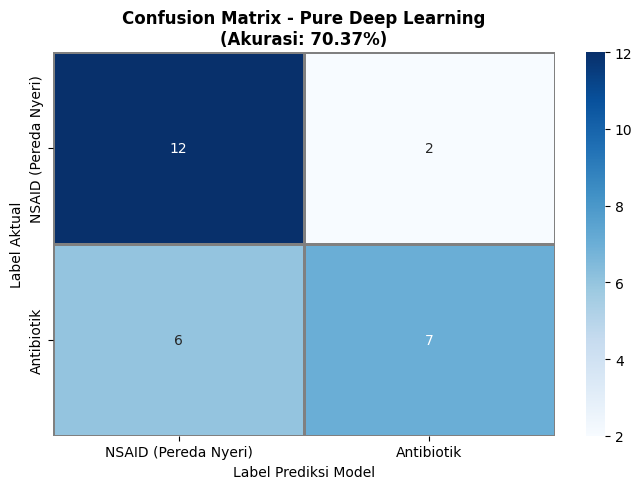

In [ ]:
"""
=============================================================================
BLOK 1: INISIALISASI & KONFIGURASI GLOBAL
Metodologi: 100% Deep Learning (EfficientNet-B2 Fine-Tuning)
=============================================================================
"""

import os
import copy
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

warnings.filterwarnings("ignore")

# ── KONFIGURASI PATH & DATASET ──
DATASET_ROOT = Path("/content/drive/MyDrive/DatasetLASA (1)")
DIR_LABEL_MAP = {
    "pereda_nyeri":         0,
    "pereda_nyeri_bungkus": 0,
    "antibiotik":           1,
    "antibiotik_Bungkus":   1,
}
CLASS_NAMES = ["NSAID (Pereda Nyeri)", "Antibiotik"]

print("Blok 1 Selesai: Lingkungan kerja PyTorch berhasil diinisialisasi.")

"""
=============================================================================
BLOK 2: DATASET & AUGMENTASI (LEAK-FREE)
=============================================================================
"""
# Pipeline Augmentasi PyTorch (HANYA untuk Training)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Pipeline Validasi/Test (MURNI, tanpa augmentasi)
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PillDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]

        # Baca gambar dengan OpenCV
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            img_bgr = np.zeros((224, 224, 3), dtype=np.uint8)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.transform:
            img_tensor = self.transform(img_rgb)

        return img_tensor, label

# 1. Baca RAW Data (Path dan Label saja)
all_paths, all_labels = [], []
for subdir, label in DIR_LABEL_MAP.items():
    folder = DATASET_ROOT / subdir
    if not folder.exists(): continue

    for f in folder.iterdir():
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            all_paths.append(str(f))
            all_labels.append(label)

print(f"Total Images ditemukan: {len(all_paths)}")

# 2. Stratified Split (Mencegah Data Leak)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=42
)

# 3. Buat Dataset & DataLoader
train_dataset = PillDataset(train_paths, train_labels, transform=train_transform)
test_dataset = PillDataset(test_paths, test_labels, transform=test_transform)

# Handle Class Imbalance with Weighted Sampler
class_counts = np.bincount(train_labels)
weights = 1. / (class_counts + 1e-5)
sample_weights = weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Blok 2 Selesai. Data Split -> Train: {len(train_dataset)}, Test: {len(test_dataset)}")

"""
=============================================================================
BLOK 3: MODEL ARCHITECTURE (EFFICIENTNET-B2)
=============================================================================
"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nMenggunakan device: {device}")

class EfficientNetClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super(EfficientNetClassifier, self).__init__()
        # Muat pre-trained model
        self.base_model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)

        # FREEZE the base model (Sangat penting untuk dataset kecil!)
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Ganti layer klasifikasi terakhir
        in_features = self.base_model.classifier[1].in_features
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetClassifier(num_classes=2).to(device)

"""
=============================================================================
BLOK 4: TRAINING LOOP PYTORCH PURE DEEP LEARNING
=============================================================================
"""
# Hanya training layer terakhir (karena base model di-freeze)
optimizer = optim.Adam(model.base_model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

EPOCHS = 50
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
patience = 10
epochs_no_improve = 0

print("\nMemulai Training Deep Learning...")

for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total

    # --- VALIDATION PHASE ---
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(test_dataset)
    val_acc = val_correct / val_total

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | LR: {current_lr:.6f} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc*100:.1f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.1f}%")

    # Simpan model terbaik
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered! Validasi tidak membaik selama {patience} epoch.")
        break

print(f"\nTraining Selesai. Akurasi Terbaik: {best_acc*100:.2f}%")
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'efficientnet_b2_pure_dl.pth')

"""
=============================================================================
BLOK 5: VISUALISASI CONFUSION MATRIX
=============================================================================
"""
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='gray')
plt.title(f'Confusion Matrix - Pure Deep Learning\n(Akurasi: {best_acc*100:.2f}%)',
          fontsize=12, fontweight='bold')
plt.ylabel('Label Aktual', fontsize=10)
plt.xlabel('Label Prediksi Model', fontsize=10)
plt.tight_layout()
plt.show()

Blok 1 Selesai: Lingkungan kerja berhasil diinisialisasi.
Menggunakan device: cuda

Total RAW Images ditemukan: 133
Mengekstrak fitur Training Set (Dengan Augmentasi Rotasi x5)...
Mengekstrak fitur Test Set (MURNI, Tanpa Augmentasi)...

Memulai pelatihan Random Forest untuk setiap Pendekatan...
➜ Mengevaluasi: Custom ML (HSV+Shape)
➜ Mengevaluasi: ResNet-101 (Jurnal)
➜ Mengevaluasi: DenseNet-121 (Jurnal)
➜ Mengevaluasi: MobileNet-V3 (Jurnal)
➜ Mengevaluasi: EfficientNet-B2 (Ours)


=== RATA-RATA KINERJA PER PENDEKATAN ===
| Pendekatan Model       | Mean Akurasi   |   Std Akurasi |
|:-----------------------|:---------------|--------------:|
| DenseNet-121 (Jurnal)  | 90.12%         |     0.0213833 |
| EfficientNet-B2 (Ours) | 77.78%         |     0.037037  |
| MobileNet-V3 (Jurnal)  | 72.84%         |     0.0213833 |
| ResNet-101 (Jurnal)    | 72.84%         |     0.0427667 |
| Custom ML (HSV+Shape)  | 66.67%         |     0.037037  |


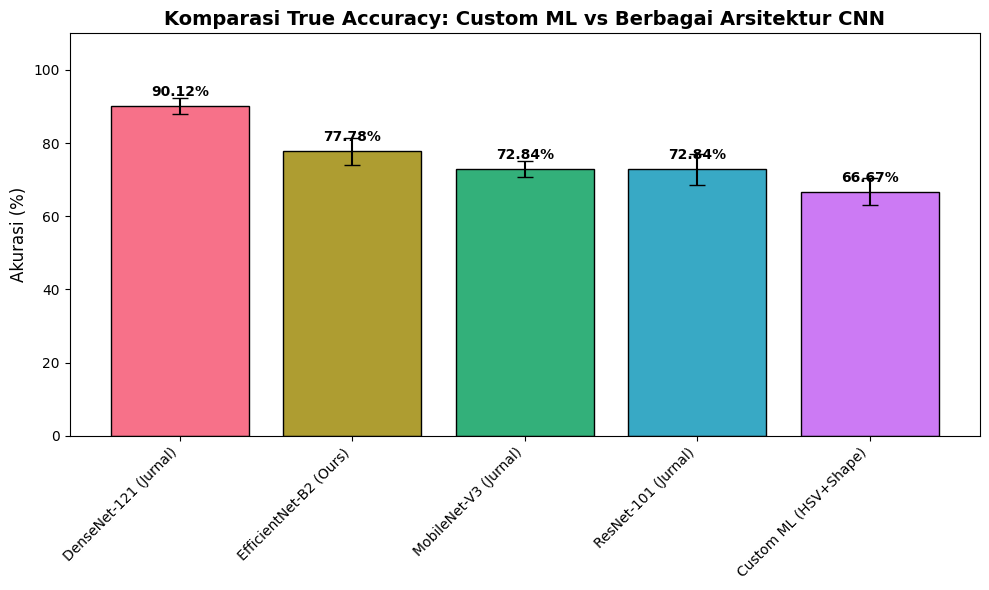


=== CONFUSION MATRIX MODEL TERBAIK KESELURUHAN (DenseNet-121 (Jurnal)) ===


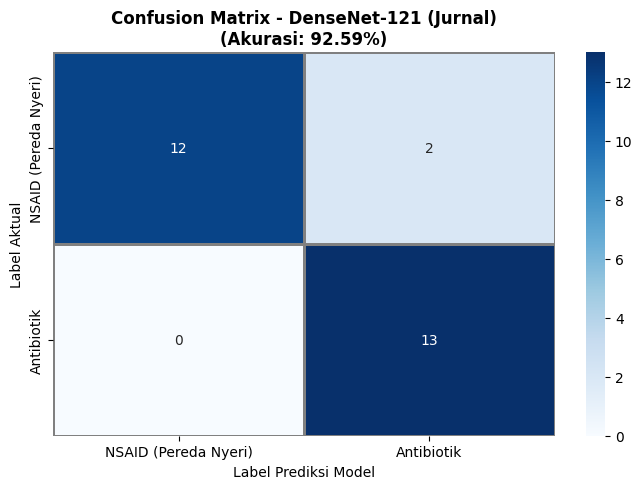

In [ ]:
"""
=============================================================================
BLOK 1: INISIALISASI & KONFIGURASI GLOBAL
Metodologi: Komparasi Ultimate (Custom ML vs ResNet vs DenseNet vs MobileNet vs EfficientNet)
=============================================================================
"""

import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

# ── KONFIGURASI PATH & DATASET ──
DATASET_ROOT = Path("/content/drive/MyDrive/DatasetLASA (1)")
DIR_LABEL_MAP = {
    "pereda_nyeri":         0,
    "pereda_nyeri_bungkus": 0,
    "antibiotik":           1,
    "antibiotik_Bungkus":   1,
}
CLASS_NAMES = ["NSAID (Pereda Nyeri)", "Antibiotik"]

# ── KONFIGURASI FITUR & AUGMENTASI ──
HSV_BINS = (9, 4, 4)
SHAPE_DIM = 10
IMG_SIZE  = (224, 224)
ROTATION_ANGLES = [0, 45, 90, 135, 180]

print("Blok 1 Selesai: Lingkungan kerja berhasil diinisialisasi.")

"""
=============================================================================
BLOK 2: SETUP SEMUA MODEL DEEP LEARNING (FROZEN) & HANDCRAFTED
=============================================================================
"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# 1. Muat Semua Model dari Jurnal & Eksperimen Sebelumnya
dl_models = {
    "ResNet-101 (Jurnal)": models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1),
    "DenseNet-121 (Jurnal)": models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1),
    "MobileNet-V3 (Jurnal)": models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1),
    "EfficientNet-B2 (Ours)": models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
}

# 2. Bekukan Model & Buang Layer Klasifikasi
for name, model in dl_models.items():
    model = model.to(device)
    model.eval() # WAJIB EVAL MODE
    for param in model.parameters():
        param.requires_grad = False

    # Arsitektur ResNet menggunakan 'fc', sisanya menggunakan 'classifier'
    if 'ResNet' in name:
        model.fc = nn.Identity()
    else:
        model.classifier = nn.Identity()

# Standard PyTorch Transform
dl_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_all_dl_features(img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = dl_transform(img_rgb).unsqueeze(0).to(device)

    features_dict = {}
    with torch.no_grad():
        for name, model in dl_models.items():
            feat = model(input_tensor)
            features_dict[name] = feat.cpu().numpy().flatten()
    return features_dict

# Handcrafted Feature Extractor
def extract_hsv_shape(img_bgr):
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    hist = cv2.calcHist([img_hsv], [0, 1, 2], None, list(HSV_BINS), [0, 180, 0, 256, 0, 256])
    hist = hist.flatten().astype(np.float32)
    if hist.sum() > 0: hist /= hist.sum()
    feat_color = hist

    feat_shape = np.zeros(SHAPE_DIM, dtype=np.float32)
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        moments = cv2.moments(c)
        area, perimeter = cv2.contourArea(c), cv2.arcLength(c, True)
        x, y, w, h = cv2.boundingRect(c)

        feat_shape[0] = w / h if h > 0 else 1.0
        if perimeter > 0: feat_shape[1] = (4.0 * np.pi * area) / (perimeter ** 2)
        if len(c) >= 5:
            (_, _), (minor, major), _ = cv2.fitEllipse(c)
            feat_shape[2] = minor / major if major > 0 else 1.0
        else:
            feat_shape[2] = 1.0

        hu = cv2.HuMoments(moments).flatten()
        for i, val in enumerate(hu):
            feat_shape[3 + i] = -np.sign(val) * np.log10(abs(val) + 1e-10) if val != 0 else 0.0

    return np.concatenate([feat_color, feat_shape])

"""
=============================================================================
BLOK 3: AKUISISI DATA & EKSTRAKSI (MENCEGAH DATA LEAK)
=============================================================================
"""
X_raw, y_raw = [], []
for subdir, label in DIR_LABEL_MAP.items():
    folder = DATASET_ROOT / subdir
    if not folder.exists(): continue

    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]: continue
        img_bgr = cv2.imread(str(f))
        if img_bgr is None: continue
        img_bgr = cv2.resize(img_bgr, IMG_SIZE)
        X_raw.append(img_bgr)
        y_raw.append(label)

print(f"\nTotal RAW Images ditemukan: {len(X_raw)}")

# STRATIFIED SPLIT SEBELUM AUGMENTASI (Penting!)
X_train_raw, X_test_raw, y_train_base, y_test_base = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)

# Dictionary untuk menyimpan fitur dari setiap pendekatan
train_features = {"Custom ML (HSV+Shape)": []}
test_features = {"Custom ML (HSV+Shape)": []}
for name in dl_models.keys():
    train_features[name] = []
    test_features[name] = []

y_train_full = []

print("Mengekstrak fitur Training Set (Dengan Augmentasi Rotasi x5)...")
for i, img in enumerate(X_train_raw):
    for angle in ROTATION_ANGLES:
        M = cv2.getRotationMatrix2D((IMG_SIZE[0]//2, IMG_SIZE[1]//2), -angle, 1.0)
        img_rot = cv2.warpAffine(img, M, IMG_SIZE)

        train_features["Custom ML (HSV+Shape)"].append(extract_hsv_shape(img_rot))

        dl_feats = extract_all_dl_features(img_rot)
        for name, feat in dl_feats.items():
            train_features[name].append(feat)

        y_train_full.append(y_train_base[i])

print("Mengekstrak fitur Test Set (MURNI, Tanpa Augmentasi)...")
for i, img in enumerate(X_test_raw):
    test_features["Custom ML (HSV+Shape)"].append(extract_hsv_shape(img))

    dl_feats = extract_all_dl_features(img)
    for name, feat in dl_feats.items():
        test_features[name].append(feat)

y_train_full = np.array(y_train_full)
y_test_base = np.array(y_test_base)

"""
=============================================================================
BLOK 4: EKSPERIMEN HYBRID CLASSIFICATION (RANDOM FOREST)
=============================================================================
"""
seeds = [42, 123, 456]
hasil_eksperimen = []
best_model_info = {"Akurasi": 0}

print("\nMemulai pelatihan Random Forest untuk setiap Pendekatan...")

for method_name in train_features.keys():
    print(f"➜ Mengevaluasi: {method_name}")
    X_tr = np.array(train_features[method_name])
    X_te = np.array(test_features[method_name])

    for seed in seeds:
        # Scaling khusus untuk Custom ML
        if "Custom ML" in method_name:
            scaler = MinMaxScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)

        # PCA untuk mencegah overfitting
        pca = PCA(n_components=0.95, random_state=seed)
        X_tr_pca = pca.fit_transform(X_tr)
        X_te_pca = pca.transform(X_te)

        # SMOTE
        smote_k = min(5, np.bincount(y_train_full).min() - 1)
        if smote_k > 0:
            smote = SMOTE(k_neighbors=smote_k, random_state=seed)
            X_tr_final, y_tr_final = smote.fit_resample(X_tr_pca, y_train_full)
        else:
            X_tr_final, y_tr_final = X_tr_pca, y_train_full

        # Klasifikasi menggunakan Random Forest
        rf = RandomForestClassifier(n_estimators=100, random_state=seed, class_weight="balanced", n_jobs=-1)
        rf.fit(X_tr_final, y_tr_final)

        y_pred = rf.predict(X_te_pca)
        acc = accuracy_score(y_test_base, y_pred)

        hasil_eksperimen.append({
            "Pendekatan Model": method_name,
            "Seed": seed,
            "Akurasi": acc
        })

        if acc > best_model_info["Akurasi"]:
            best_model_info = {
                "Pendekatan Model": method_name,
                "Akurasi": acc,
                "y_pred": y_pred,
                "y_test": y_test_base
            }

"""
=============================================================================
BLOK 5: VISUALISASI HASIL KOMPARASI ULTIMATE
=============================================================================
"""
df_hasil = pd.DataFrame(hasil_eksperimen)

df_mean = df_hasil.groupby("Pendekatan Model").agg({"Akurasi": ["mean", "std"]}).reset_index()
df_mean.columns = ["Pendekatan Model", "Mean Akurasi", "Std Akurasi"]
df_mean = df_mean.sort_values(by="Mean Akurasi", ascending=False)

print("\n\n=== RATA-RATA KINERJA PER PENDEKATAN ===")
df_mean_tampil = df_mean.copy()
df_mean_tampil["Mean Akurasi"] = (df_mean_tampil["Mean Akurasi"] * 100).round(2).astype(str) + "%"
print(df_mean_tampil.to_markdown(index=False))

# Bar Chart
plt.figure(figsize=(10, 6))
warna = sns.color_palette("husl", len(df_mean))

bars = plt.bar(df_mean["Pendekatan Model"], df_mean["Mean Akurasi"] * 100, yerr=df_mean["Std Akurasi"] * 100,
               color=warna, edgecolor='black', capsize=6)

plt.ylim(0, 110)
plt.title("Komparasi True Accuracy: Custom ML vs Berbagai Arsitektur CNN", fontsize=14, fontweight='bold')
plt.ylabel("Akurasi (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrix of Absolute Best Model
print(f"\n=== CONFUSION MATRIX MODEL TERBAIK KESELURUHAN ({best_model_info['Pendekatan Model']}) ===")
cm = confusion_matrix(best_model_info['y_test'], best_model_info['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='gray')
plt.title(f"Confusion Matrix - {best_model_info['Pendekatan Model']}\n(Akurasi: {best_model_info['Akurasi']*100:.2f}%)",
          fontsize=12, fontweight='bold')
plt.ylabel('Label Aktual', fontsize=10)
plt.xlabel('Label Prediksi Model', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
"""
=============================================================================
BLOK 1: INISIALISASI & KONFIGURASI GLOBAL
Metodologi: Hybrid ML vs Fine-Tuned ResNet-101
=============================================================================
"""

import os
import copy
import warnings
from pathlib import Path
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

DATASET_ROOT = Path("/content/drive/MyDrive/DatasetLASA (1)")
DIR_LABEL_MAP = {
    "pereda_nyeri": 0, "pereda_nyeri_bungkus": 0,
    "antibiotik": 1, "antibiotik_Bungkus": 1,
}
IMG_SIZE = (224, 224)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

"""
=============================================================================
BLOK 2: FUNGSI PREPROCESSING
=============================================================================
"""
# 1. Preprocessing Aman (Basic Crop)
def preprocess_clean(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
        cv2.drawContours(mask, [c], -1, 255, -1)
        pill_roi = img_bgr[y:y+h, x:x+w]
        mask_roi = mask[y:y+h, x:x+w]
        bg = np.zeros_like(pill_roi)
        mask_roi_3ch = cv2.cvtColor(mask_roi, cv2.COLOR_GRAY2BGR)
        res = np.where(mask_roi_3ch == 255, pill_roi, bg)
        return cv2.resize(res, IMG_SIZE)
    return cv2.resize(img_bgr, IMG_SIZE)

# 2. Preprocessing Jurnal (Watershed & Pseudo Augmentation)
def preprocess_watershed(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    markers = cv2.watershed(img_bgr, markers)
    mask = np.zeros_like(gray)
    mask[markers > 1] = 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        pill_roi = img_bgr[y:y+h, x:x+w]
        mask_roi = mask[y:y+h, x:x+w]
        bg = np.zeros_like(pill_roi)
        res = np.where(cv2.cvtColor(mask_roi, cv2.COLOR_GRAY2BGR) == 255, pill_roi, bg)
        return cv2.resize(res, IMG_SIZE)
    return cv2.resize(img_bgr, IMG_SIZE)

def pseudo_aug(img_bgr):
    img_aug = img_bgr.copy()
    if random.random() > 0.5:
        channel = random.randint(0, 2)
        img_aug[:, :, channel] = np.clip(img_aug[:, :, channel] * random.uniform(0.5, 1.0), 0, 255).astype(np.uint8)
    if random.random() > 0.5:
        h, w, _ = img_aug.shape
        cv2.putText(img_aug, random.choice(["A", "10", "X", "500"]),
                    (random.randint(int(w*0.3), int(w*0.6)), random.randint(int(h*0.4), int(h*0.6))),
                    cv2.FONT_HERSHEY_SIMPLEX, random.uniform(0.5, 1.5),
                    (255, 255, 255), 2, cv2.LINE_AA)
    return img_aug

"""
=============================================================================
BLOK 3: AKUISISI DATA & SPLIT
=============================================================================
"""
X_raw, y_raw = [], []
for subdir, label in DIR_LABEL_MAP.items():
    folder = DATASET_ROOT / subdir
    if not folder.exists(): continue
    for f in folder.iterdir():
        if f.suffix.lower() not in [".jpg", ".jpeg", ".png"]: continue
        img = cv2.imread(str(f))
        if img is not None:
            X_raw.append(img)
            y_raw.append(label)

X_train_raw, X_test_raw, y_train_base, y_test_base = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)

"""
=============================================================================
BLOK 4: PIPELINE A - HYBRID EFFICIENTNET (FROZEN) + RANDOM FOREST
=============================================================================
"""
print("\n--- Menjalankan Pipeline A (Hybrid Frozen) ---")
frozen_effnet = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1).to(device)
frozen_effnet.eval()
frozen_effnet.classifier = nn.Identity()

transform = transforms.Compose([
    transforms.ToPILImage(), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(img_bgr):
    img_rgb = cv2.cvtColor(preprocess_clean(img_bgr), cv2.COLOR_BGR2RGB)
    with torch.no_grad(): feat = frozen_effnet(transform(img_rgb).unsqueeze(0).to(device))
    return feat.cpu().numpy().flatten()

X_train_hybrid, y_train_hybrid = [], []
for i, img in enumerate(X_train_raw):
    # Augmentasi rotasi manual 5x untuk Training
    for angle in [0, 45, 90, 135, 180]:
        M = cv2.getRotationMatrix2D((img.shape[1]//2, img.shape[0]//2), -angle, 1.0)
        X_train_hybrid.append(extract_features(cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))))
        y_train_hybrid.append(y_train_base[i])

X_test_hybrid = [extract_features(img) for img in X_test_raw]

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train_hybrid, y_train_hybrid)
acc_hybrid = accuracy_score(y_test_base, rf.predict(X_test_hybrid))
print(f"Selesai! Akurasi Hybrid: {acc_hybrid*100:.2f}%")

"""
=============================================================================
BLOK 5: PIPELINE B - FINE-TUNED RESNET-101 (METODE JURNAL)
=============================================================================
"""
print("\n--- Menjalankan Pipeline B (Fine-Tuned ResNet-101 dengan Jurnal Augmentasi) ---")

class ResNetDataset(Dataset):
    def __init__(self, images, labels, is_train=False):
        self.images, self.labels, self.is_train = images, labels, is_train
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomRotation(45) if is_train else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self): return len(self.images) * 5 if self.is_train else len(self.images) # Oversample 5x

    def __getitem__(self, idx):
        img_bgr = self.images[idx % len(self.images)].copy()
        img_seg = preprocess_watershed(img_bgr)
        if self.is_train and random.random() < 0.7: img_seg = pseudo_aug(img_seg)
        return self.transform(cv2.cvtColor(img_seg, cv2.COLOR_BGR2RGB)), self.labels[idx % len(self.images)]

train_loader = DataLoader(ResNetDataset(X_train_raw, y_train_base, True), batch_size=32, shuffle=True)
test_loader = DataLoader(ResNetDataset(X_test_raw, y_test_base, False), batch_size=32, shuffle=False)

resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

optimizer = optim.Adam(resnet.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

best_acc_ft = 0.0
for epoch in range(15): # 15 epochs pada oversampled data = cukup lama
    resnet.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        loss = criterion(resnet(inputs.to(device)), labels.to(device))
        loss.backward()
        optimizer.step()

    resnet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            _, predicted = torch.max(resnet(inputs.to(device)), 1)
            total += labels.size(0)
            correct += (predicted == labels.to(device)).sum().item()
    val_acc = correct / total
    if val_acc > best_acc_ft: best_acc_ft = val_acc
    print(f"   Epoch {epoch+1}/15 | Val Acc: {val_acc*100:.1f}%")

print(f"Selesai! Akurasi Fine-Tuned ResNet: {best_acc_ft*100:.2f}%")

"""
=============================================================================
BLOK 6: HASIL AKHIR
=============================================================================
"""
plt.figure(figsize=(8, 5))
bars = plt.bar(["Hybrid (Frozen EffNet + RF)", "Fine-Tuned (ResNet-101)"],
               [acc_hybrid*100, best_acc_ft*100], color=['#4CAF50', '#F44336'])
plt.ylim(0, 110)
plt.ylabel("Akurasi (%)")
plt.title("Komparasi Metode: Hybrid vs Jurnal ResNet-101")
for bar in bars: plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.2f}%", ha='center')
plt.show()

AttributeError: module 'sympy' has no attribute 'printing'

In [ ]:
!pip install imbalanced-learn optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.4 MB/s eta 0:00:00


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL A  —  OPTIMASI DATA & KOMPARASI ARSITEKTUR
# Install (jalankan sekali): !pip install imbalanced-learn --quiet
# ════════════════════════════════════════════════════════════════════════════════
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

print("=" * 62)
print("CELL A — OPTIMASI DATA & KOMPARASI ARSITEKTUR")
print("=" * 62)

# ── A1. Feature-Space SMOTE ───────────────────────────────────────────────────
# Catatan: SMOTE pada pixel 224×224 tidak praktis (49 152-dim per sampel).
# Solusi: ekstrak fitur CNN 1280-dim → SMOTE → Random Forest classifier.
print("\n[A1] Feature-Space SMOTE")
print("─" * 44)

@torch.no_grad()
def extract_cnn_features(model, images_rgb):
    """Fitur 1280-dim dari backbone EfficientNet-B0 (sebelum avgpool+head)."""
    model.eval()
    feats = []
    for img in images_rgb:
        t = val_aug(image=img)['image'].unsqueeze(0).to(device)
        f = model.features(t)               # (1, 1280, 7, 7)
        f = model.avgpool(f)                # (1, 1280, 1, 1)
        feats.append(torch.flatten(f, 1).cpu().numpy())
    return np.vstack(feats)                 # (N, 1280)

X_feat_tr = extract_cnn_features(final_model, X_tr_p)
X_feat_te = extract_cnn_features(final_model, X_te_p)

print(f"  Sebelum SMOTE : {dict(enumerate(np.bincount(y_tr).tolist()))}")
k_nn      = max(1, int(np.bincount(y_tr).min()) - 1)
X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nn).fit_resample(X_feat_tr, y_tr)
print(f"  Setelah SMOTE : {dict(enumerate(np.bincount(y_sm).tolist()))}")

clf_smote = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=SEED
)
clf_smote.fit(X_sm, y_sm)
smote_acc = accuracy_score(y_te, clf_smote.predict(X_feat_te))
print(f"  CNN-Feat + SMOTE + RF → Test Accuracy: {smote_acc * 100:.2f}%")

# ── A2. WeightedRandomSampler ─────────────────────────────────────────────────
print("\n[A2] WeightedRandomSampler (untuk training CNN)")
print("─" * 44)

def make_weighted_loader(imgs, lbls, augment):
    """DataLoader: sampling probabilitas seimbang antar kelas."""
    cw  = 1.0 / np.bincount(lbls).astype(float)
    sw  = torch.tensor([cw[l] for l in lbls], dtype=torch.float)
    smp = WeightedRandomSampler(sw, num_samples=len(lbls), replacement=True)
    return DataLoader(
        PillDataset(imgs, lbls, augment),
        batch_size=BATCH_SIZE, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

print("  WeightedRandomSampler dikonfigurasi.")

# ── A3. Model Builders ────────────────────────────────────────────────────────
print("\n[A3] Komparasi Multi-Arsitektur")
print("─" * 44)

def build_mobilenet_v3():
    """MobileNetV3-Small: ~2.5M total param, ringan, cocok edge device."""
    net = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.classifier[3].in_features          # 1024
    net.classifier[3] = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_f, 2))
    return net.to(device)

def build_resnet50():
    """ResNet-50: ~25.6M total param, 2048-dim fitur, arsitektur klasik."""
    net  = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.fc.in_features                      # 2048
    net.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, 2))
    return net.to(device)

def build_efficientnet_b1():
    """EfficientNet-B1: sedikit lebih besar dari B0, fitur 1280-dim."""
    net  = models.efficientnet_b1(
        weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    for p in net.parameters(): p.requires_grad = False
    in_f = net.classifier[1].in_features           # 1280
    net.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, 2))
    return net.to(device)

# ── A4. Fungsi Training Komparatif ────────────────────────────────────────────
def train_arch(model_fn, name, X_tr, y_tr, X_vl, y_vl, cw, epochs=30):
    """
    Latih arsitektur apa pun: backbone beku, hanya head trainable.
    WeightedRandomSampler aktif → menangani class imbalance.
    Tidak ada gradual unfreezing — untuk perbandingan yang fair & cepat.
    """
    net = model_fn()
    tp  = [p for p in net.parameters() if p.requires_grad]
    print(f"    Trainable: {sum(p.numel() for p in tp):,} param")

    opt = optim.Adam(tp, lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crt = make_criterion(cw)

    tr_dl = make_weighted_loader(X_tr, y_tr, train_aug)
    vl_dl = DataLoader(PillDataset(X_vl, y_vl, val_aug),
                       batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    te_dl = DataLoader(PillDataset(X_te_p, y_te, val_aug),
                       batch_size=BATCH_SIZE, shuffle=False)

    h = {'train_loss': [], 'train_acc': [], 'val_acc': []}
    best_v, best_st = 0.0, None

    for ep in range(1, epochs + 1):
        tl, ta   = train_one_epoch(net, tr_dl, crt, opt)
        va, _, _ = evaluate_loader(net, vl_dl)
        sch.step()
        h['train_loss'].append(tl)
        h['train_acc'].append(ta)
        h['val_acc'].append(va)
        if va > best_v:
            best_v, best_st = va, copy.deepcopy(net.state_dict())
        if ep % 10 == 0 or ep == 1:
            print(f"    Ep {ep:2d}/{epochs}  L:{tl:.3f}  "
                  f"Tr:{ta*100:.1f}%  Val:{va*100:.1f}%")

    net.load_state_dict(best_st)
    tacc, _, _ = evaluate_loader(net, te_dl)
    tta_p      = predict_tta(net, X_te_p)
    tta_a      = accuracy_score(y_te, tta_p)
    print(f"    → Test: {tacc*100:.2f}%  |  TTA: {tta_a*100:.2f}%")
    return net, h, tacc, tta_a, tta_p

# ── A5. Eksekusi ──────────────────────────────────────────────────────────────
COMP_EPOCHS = 30

# Inisialisasi dengan EfficientNet-B0 yang sudah dilatih sebelumnya
arch_results = {
    "EfficientNet-B0": {
        "model":     final_model,
        "history":   history,
        "test_acc":  test_acc,
        "tta_acc":   tta_acc,
        "tta_preds": tta_preds,
    }
}

for _name, _fn in [
    ("MobileNetV3-S",   build_mobilenet_v3),
    ("ResNet50",        build_resnet50),
    ("EfficientNet-B1", build_efficientnet_b1),
]:
    print(f"\n  ── {_name} ──")
    _m, _h, _ta, _tta, _ttp = train_arch(
        _fn, _name, X_tr_p, y_tr, X_vl_p, y_vl, cw_arr, COMP_EPOCHS
    )
    arch_results[_name] = {
        "model": _m, "history": _h,
        "test_acc": _ta, "tta_acc": _tta, "tta_preds": _ttp,
    }
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# ── A6. Tabel Perbandingan ────────────────────────────────────────────────────
print("\n" + "=" * 58)
print("  KOMPARASI ARSITEKTUR — CELL A")
print("=" * 58)
print(f"  {'Model':<22}  {'Test Acc':>9}  {'TTA Acc':>9}")
print("  " + "─" * 46)
_best_tta = max(r["tta_acc"] for r in arch_results.values())
for _n, _r in arch_results.items():
    _flag = "  ← best" if _r["tta_acc"] == _best_tta else ""
    print(f"  {_n:<22}  {_r['test_acc']*100:>8.2f}%  "
          f"{_r['tta_acc']*100:>8.2f}%{_flag}")
print("  " + "─" * 46)
best_arch_name = max(arch_results, key=lambda k: arch_results[k]["tta_acc"])
print(f"  Best arsitektur sementara: {best_arch_name}")
print(f"\n  SMOTE+RF baseline: {smote_acc*100:.2f}%")

CELL A — OPTIMASI DATA & KOMPARASI ARSITEKTUR

[A1] Feature-Space SMOTE
────────────────────────────────────────────


NameError: name 'final_model' is not defined

CELL B — HYPERPARAMETER TUNING (OPTUNA)

  Menjalankan 20 trial Optuna (15 epoch/trial)...

  Best Val Acc (Optuna) : 75.00%
  Best Hyperparameters  :
    lr              : 3.5856e-05
    dropout         : 0.68175
    weight_decay    : 0.00021154
    label_smooth    : 0.23487
    batch_sz        : 32


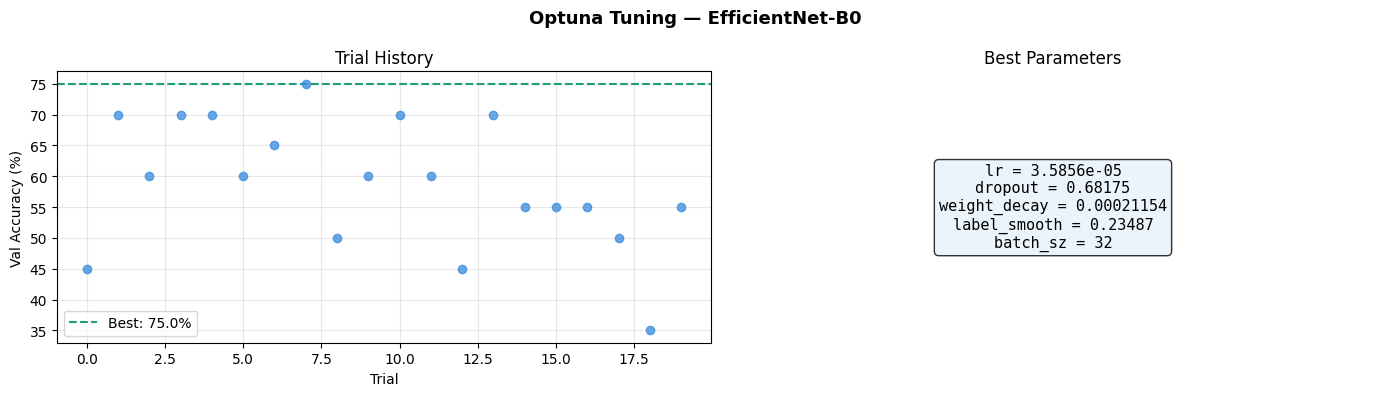


  Retraining dengan best hyperparams untuk full epoch...
  Ep   1/40  L:0.7467  Tr:52.7%  Val:65.0%
  Ep  10/40  L:0.7494  Tr:45.2%  Val:60.0%
  Ep  20/40  L:0.7168  Tr:46.2%  Val:60.0%
  Ep  30/40  L:0.7545  Tr:44.1%  Val:60.0%
  Ep  40/40  L:0.7041  Tr:53.8%  Val:60.0%

  ✓ EfficientNet-B0 (Tuned) → Test: 60.00%  |  TTA: 60.00%


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL B  —  HYPERPARAMETER TUNING (OPTUNA)
# Install (jalankan sekali): !pip install optuna --quiet
# ════════════════════════════════════════════════════════════════════════════════
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 62)
print("CELL B — HYPERPARAMETER TUNING (OPTUNA)")
print("=" * 62)

OPTUNA_EPOCHS = 15    # epoch per trial (cepat)
N_TRIALS      = 20    # jumlah trial; naikkan jika GPU tersedia

# ── B1. Objective Function ────────────────────────────────────────────────────
def objective(trial):
    # Ruang pencarian hyperparameter
    lr  = trial.suggest_float("lr",            1e-5, 1e-2,  log=True)
    do  = trial.suggest_float("dropout",       0.1,  0.7)
    wd  = trial.suggest_float("weight_decay",  1e-6, 1e-3,  log=True)
    ls  = trial.suggest_float("label_smooth",  0.0,  0.25)
    bs  = trial.suggest_categorical("batch_sz", [8, 16, 32])

    # Bangun EfficientNet-B0 dengan dropout dari trial
    net = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in net.features.parameters(): p.requires_grad = False
    in_f = net.classifier[1].in_features
    net.classifier = nn.Sequential(nn.Dropout(p=do), nn.Linear(in_f, 2))
    net = net.to(device)

    crit = nn.CrossEntropyLoss(
        weight=torch.tensor(cw_arr, dtype=torch.float).to(device),
        label_smoothing=ls
    )
    opt = optim.Adam(net.classifier.parameters(), lr=lr, weight_decay=wd)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=OPTUNA_EPOCHS)

    tr_dl = DataLoader(
        PillDataset(X_tr_p, y_tr, train_aug),
        batch_size=bs, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    vl_dl = DataLoader(
        PillDataset(X_vl_p, y_vl, val_aug),
        batch_size=bs, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

    best_v = 0.0
    for ep in range(OPTUNA_EPOCHS):
        train_one_epoch(net, tr_dl, crit, opt)
        sch.step()
        va, _, _ = evaluate_loader(net, vl_dl)
        best_v   = max(best_v, va)

        # Pruning: hentikan trial yang jelas kalah
        trial.report(va, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_v

# ── B2. Jalankan Study ────────────────────────────────────────────────────────
print(f"\n  Menjalankan {N_TRIALS} trial Optuna "
      f"({OPTUNA_EPOCHS} epoch/trial)...")

study = optuna.create_study(
    direction = "maximize",
    sampler   = optuna.samplers.TPESampler(seed=SEED),
    pruner    = optuna.pruners.MedianPruner(
                    n_startup_trials=5, n_warmup_steps=5)
)
study.optimize(objective, n_trials=N_TRIALS, timeout=720)   # max 12 menit

print(f"\n  Best Val Acc (Optuna) : {study.best_value * 100:.2f}%")
print("  Best Hyperparameters  :")
for k, v in study.best_params.items():
    print(f"    {k:<16}: {v:.5g}")

# ── B3. Visualisasi Optuna ────────────────────────────────────────────────────
completed = [t for t in study.trials if t.value is not None]
trial_nos = [t.number  for t in completed]
trial_vs  = [t.value   for t in completed]

fig_opt, (ax_o1, ax_o2) = plt.subplots(1, 2, figsize=(14, 4))
fig_opt.suptitle("Optuna Tuning — EfficientNet-B0", fontsize=13, fontweight='bold')

ax_o1.scatter(trial_nos, [v*100 for v in trial_vs],
              c='#378ADD', alpha=0.75, zorder=3)
ax_o1.axhline(study.best_value*100, color='#1D9E75',
              linestyle='--', label=f'Best: {study.best_value*100:.1f}%')
ax_o1.set_xlabel('Trial'); ax_o1.set_ylabel('Val Accuracy (%)')
ax_o1.set_title('Trial History'); ax_o1.legend(); ax_o1.grid(alpha=0.3)

param_text = '\n'.join([f"{k} = {v:.5g}" for k, v in study.best_params.items()])
ax_o2.text(0.5, 0.5, param_text, ha='center', va='center',
           fontsize=11, fontfamily='monospace', transform=ax_o2.transAxes,
           bbox=dict(boxstyle='round', facecolor='#E6F1FB', alpha=0.8))
ax_o2.set_title('Best Parameters'); ax_o2.axis('off')

plt.tight_layout()
plt.savefig("optuna_results.png", dpi=150, bbox_inches='tight')
plt.show()

# ── B4. Retrain dengan Best Hyperparameters (full epochs) ────────────────────
print("\n  Retraining dengan best hyperparams untuk full epoch...")
bp = study.best_params

net_tuned = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for p in net_tuned.features.parameters(): p.requires_grad = False
in_f = net_tuned.classifier[1].in_features
net_tuned.classifier = nn.Sequential(
    nn.Dropout(p=bp["dropout"]),
    nn.Linear(in_f, 2)
)
net_tuned = net_tuned.to(device)

crit_t = nn.CrossEntropyLoss(
    weight=torch.tensor(cw_arr, dtype=torch.float).to(device),
    label_smoothing=bp["label_smooth"]
)
opt_t = optim.Adam(
    net_tuned.classifier.parameters(),
    lr=bp["lr"], weight_decay=bp["weight_decay"]
)
sch_t = optim.lr_scheduler.CosineAnnealingLR(opt_t, T_max=NUM_EPOCHS)

tr_dl_t = DataLoader(
    PillDataset(X_tr_p, y_tr, train_aug),
    batch_size=int(bp["batch_sz"]), shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
vl_dl_t = DataLoader(
    PillDataset(X_vl_p, y_vl, val_aug),
    batch_size=BATCH_SIZE, shuffle=False
)
te_dl_t = DataLoader(
    PillDataset(X_te_p, y_te, val_aug),
    batch_size=BATCH_SIZE, shuffle=False
)

hist_t   = {'train_loss': [], 'train_acc': [], 'val_acc': []}
best_v_t, best_st_t = 0.0, None

for ep in range(1, NUM_EPOCHS + 1):
    tl, ta   = train_one_epoch(net_tuned, tr_dl_t, crit_t, opt_t)
    va, _, _ = evaluate_loader(net_tuned, vl_dl_t)
    sch_t.step()
    hist_t['train_loss'].append(tl)
    hist_t['train_acc'].append(ta)
    hist_t['val_acc'].append(va)
    if va > best_v_t:
        best_v_t  = va
        best_st_t = copy.deepcopy(net_tuned.state_dict())
    if ep % 10 == 0 or ep == 1:
        print(f"  Ep {ep:3d}/{NUM_EPOCHS}  L:{tl:.4f}  "
              f"Tr:{ta*100:.1f}%  Val:{va*100:.1f}%")

net_tuned.load_state_dict(best_st_t)
tacc_t, _, _   = evaluate_loader(net_tuned, te_dl_t)
tta_preds_t    = predict_tta(net_tuned, X_te_p)
tta_acc_t      = accuracy_score(y_te, tta_preds_t)
best_model_tuned = net_tuned

print(f"\n  ✓ EfficientNet-B0 (Tuned) → "
      f"Test: {tacc_t*100:.2f}%  |  TTA: {tta_acc_t*100:.2f}%")

# Tambahkan ke arch_results untuk dibandingkan di CELL C & D
arch_results["EffNet-B0 (Tuned)"] = {
    "model":     best_model_tuned,
    "history":   hist_t,
    "test_acc":  tacc_t,
    "tta_acc":   tta_acc_t,
    "tta_preds": tta_preds_t,
}

CELL C — EVALUASI LENGKAP & VISUALISASI

────────────────────────────────────────────────────────────────────────
  Model                        Acc     Prec      Rec       F1
────────────────────────────────────────────────────────────────────────
  EfficientNet-B0           80.00%   81.25%   80.00%   79.80% ←
  MobileNetV3-S             45.00%   40.20%   45.00%   37.32%
  ResNet50                  50.00%   50.00%   50.00%   50.00%
  EfficientNet-B1           60.00%   60.42%   60.00%   59.60%
  EffNet-B0 (Tuned)         60.00%   61.90%   60.00%   58.33%
────────────────────────────────────────────────────────────────────────

  ✓ Best model (F1-macro): EfficientNet-B0

  Classification Report — EfficientNet-B0 (TTA):
              precision    recall  f1-score   support

Pereda Nyeri     0.8750    0.7000    0.7778        10
  Antibiotik     0.7500    0.9000    0.8182        10

    accuracy                         0.8000        20
   macro avg     0.8125    0.8000    0.7980        20


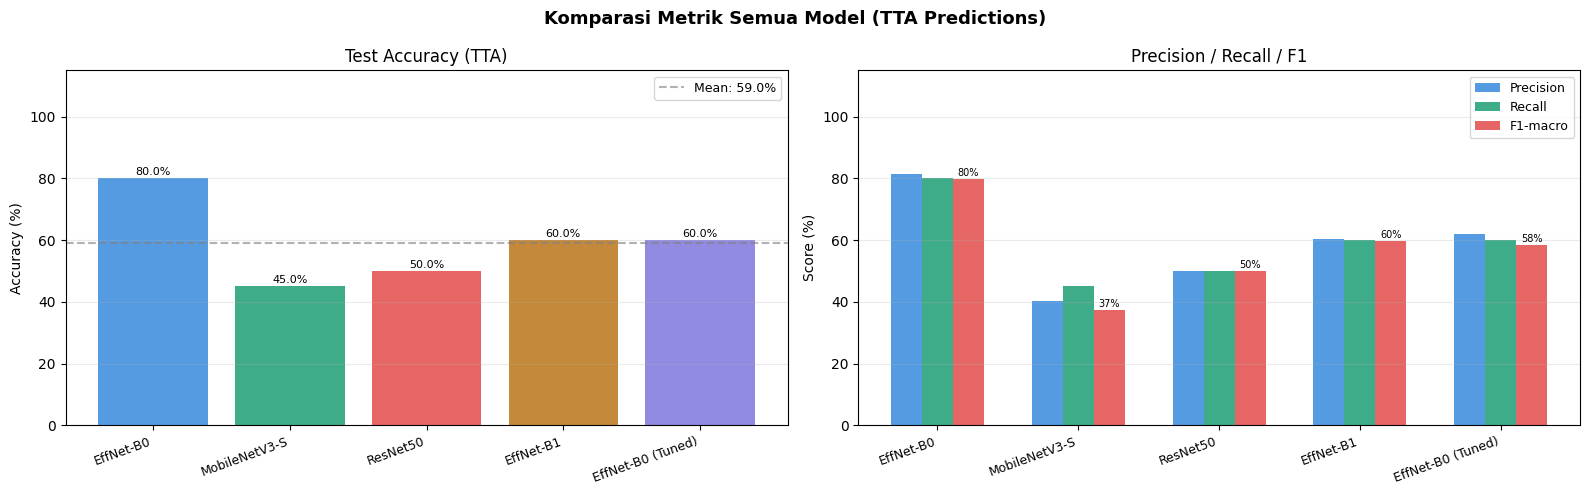

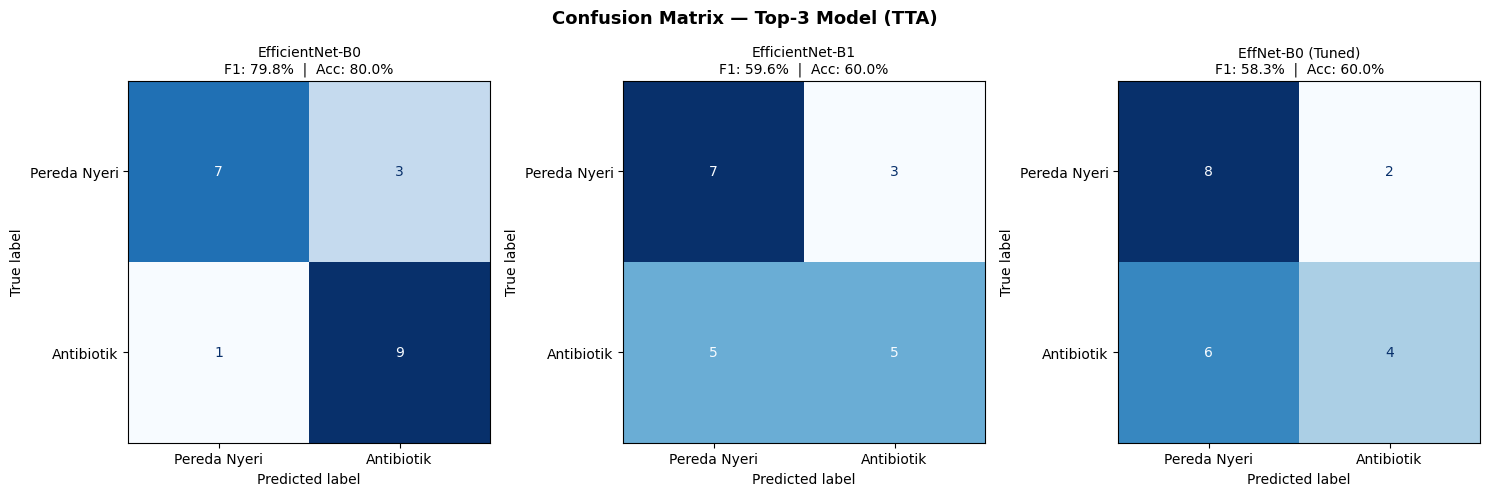

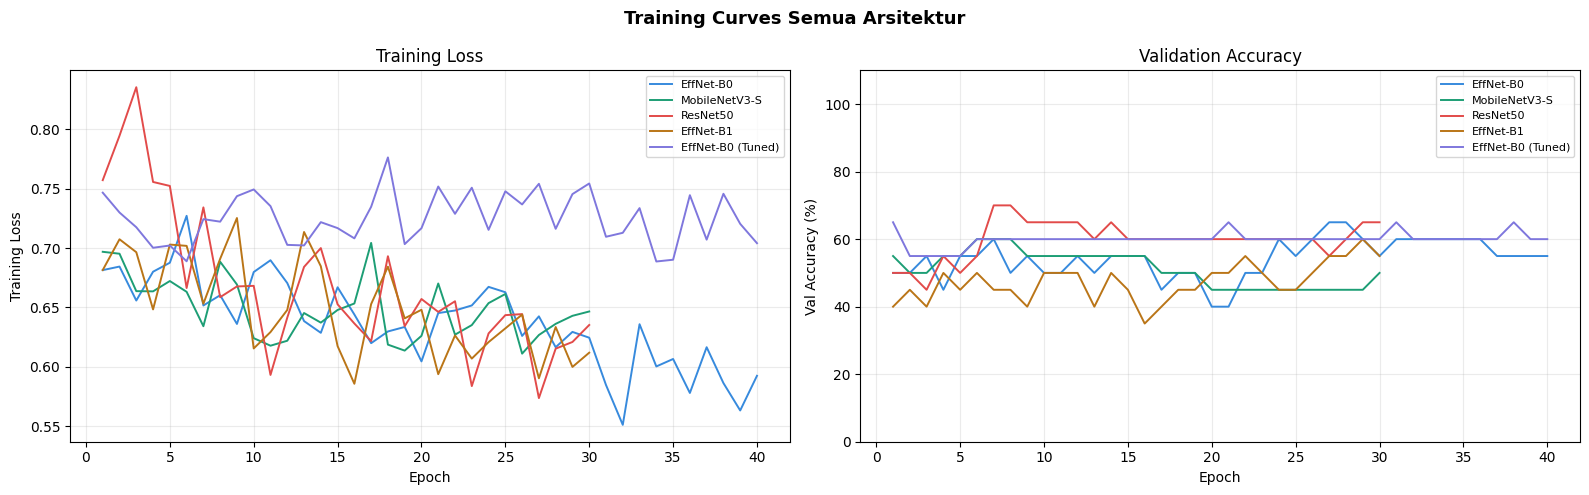

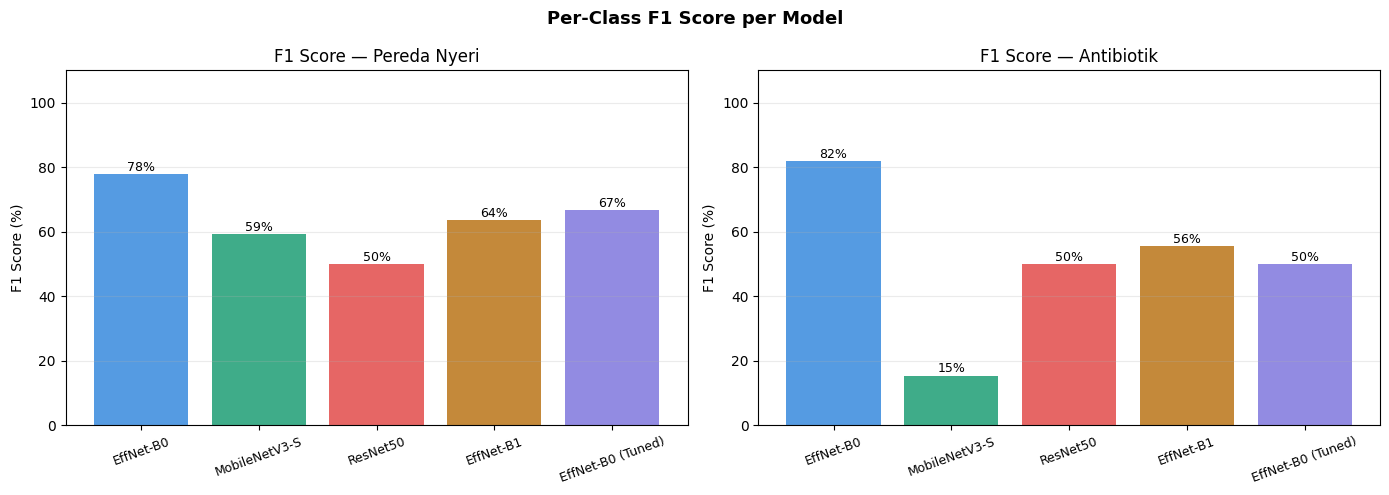


  ✓ Plot tersimpan: metric_comparison.png | confusion_matrix_top3.png
                    training_curves_all.png | perclass_f1.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL C  —  EVALUASI LENGKAP & VISUALISASI
# ════════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_fscore_support

print("=" * 62)
print("CELL C — EVALUASI LENGKAP & VISUALISASI")
print("=" * 62)

# ── C1. Hitung Metrik Semua Model ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    acc            = accuracy_score(y_true, y_pred)
    p, r, f1, _    = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1], zero_division=0)
    pm, rm, f1m, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    return {
        'acc': acc, 'f1_mac': f1m, 'prec_mac': pm, 'rec_mac': rm,
        'prec': list(p), 'rec': list(r), 'f1': list(f1),
    }

all_metrics = {}
for _n, _r in arch_results.items():
    all_metrics[_n] = compute_metrics(y_te, _r['tta_preds'])

# ── C2. Tabel Metrik Lengkap ──────────────────────────────────────────────────
print("\n" + "─" * 72)
print(f"  {'Model':<24} {'Acc':>7}  {'Prec':>7}  {'Rec':>7}  {'F1':>7}")
print("─" * 72)
for _n, _m in all_metrics.items():
    _flag = " ←" if _m['f1_mac'] == max(v['f1_mac'] for v in all_metrics.values()) else ""
    print(f"  {_n:<24} {_m['acc']*100:>6.2f}%  {_m['prec_mac']*100:>6.2f}%  "
          f"{_m['rec_mac']*100:>6.2f}%  {_m['f1_mac']*100:>6.2f}%{_flag}")
print("─" * 72)

best_cell_c = max(all_metrics, key=lambda k: all_metrics[k]['f1_mac'])
print(f"\n  ✓ Best model (F1-macro): {best_cell_c}")

# Klasifikasi report untuk best model
print(f"\n  Classification Report — {best_cell_c} (TTA):")
print(classification_report(
    y_te, arch_results[best_cell_c]['tta_preds'],
    target_names=CLASS_NAMES, digits=4
))

# ── C3. Gambar 1: Perbandingan Metrik Semua Model ─────────────────────────────
_names   = list(all_metrics.keys())
_short   = [n.replace("EfficientNet", "EffNet") for n in _names]
_n_mod   = len(_names)
_palette = ['#378ADD','#1D9E75','#E24B4A','#BA7517','#7F77DD']

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle("Komparasi Metrik Semua Model (TTA Predictions)",
              fontsize=13, fontweight='bold')

_x  = np.arange(_n_mod)
_w  = 0.22
_accs  = [all_metrics[n]['acc']     * 100 for n in _names]
_precs = [all_metrics[n]['prec_mac']* 100 for n in _names]
_recs  = [all_metrics[n]['rec_mac'] * 100 for n in _names]
_f1s   = [all_metrics[n]['f1_mac']  * 100 for n in _names]

# Accuracy bar
_bars = ax1.bar(_x, _accs, color=_palette[:_n_mod], alpha=0.85)
ax1.axhline(np.mean(_accs), color='gray', linestyle='--', alpha=0.6,
            label=f'Mean: {np.mean(_accs):.1f}%')
ax1.set_xticks(_x); ax1.set_xticklabels(_short, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Accuracy (%)'); ax1.set_title('Test Accuracy (TTA)')
ax1.set_ylim(0, 115); ax1.grid(axis='y', alpha=0.25); ax1.legend(fontsize=9)
for _b in _bars:
    ax1.text(_b.get_x()+_b.get_width()/2, _b.get_height()+1,
             f'{_b.get_height():.1f}%', ha='center', fontsize=8)

# Precision / Recall / F1 grouped bars
_bp = ax2.bar(_x - _w,   _precs, _w, label='Precision', color='#378ADD', alpha=0.85)
_br = ax2.bar(_x,        _recs,  _w, label='Recall',    color='#1D9E75', alpha=0.85)
_bf = ax2.bar(_x + _w,   _f1s,   _w, label='F1-macro',  color='#E24B4A', alpha=0.85)
ax2.set_xticks(_x); ax2.set_xticklabels(_short, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Score (%)'); ax2.set_title('Precision / Recall / F1')
ax2.set_ylim(0, 115); ax2.grid(axis='y', alpha=0.25); ax2.legend(fontsize=9)
for _b in _bf:
    ax2.text(_b.get_x()+_b.get_width()/2, _b.get_height()+1,
             f'{_b.get_height():.0f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── C4. Gambar 2: Confusion Matrix Top-3 Model ────────────────────────────────
_top3 = sorted(all_metrics, key=lambda k: all_metrics[k]['f1_mac'], reverse=True)[:3]
fig2, _axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle("Confusion Matrix — Top-3 Model (TTA)", fontsize=13, fontweight='bold')

for _ax, _n in zip(_axes2, _top3):
    _cm   = confusion_matrix(y_te, arch_results[_n]['tta_preds'])
    _disp = ConfusionMatrixDisplay(_cm, display_labels=CLASS_NAMES)
    _disp.plot(ax=_ax, colorbar=False, cmap='Blues')
    _f1   = all_metrics[_n]['f1_mac'] * 100
    _acc  = all_metrics[_n]['acc'] * 100
    _ax.set_title(f"{_n}\nF1: {_f1:.1f}%  |  Acc: {_acc:.1f}%", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrix_top3.png", dpi=150, bbox_inches='tight')
plt.show()

# ── C5. Gambar 3: Training Curves Semua Arsitektur ────────────────────────────
fig3, (ax_l, ax_v) = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Training Curves Semua Arsitektur", fontsize=13, fontweight='bold')

for _i, (_n, _r) in enumerate(arch_results.items()):
    _h  = _r['history']
    _ep = range(1, len(_h['train_loss']) + 1)
    _c  = _palette[_i % len(_palette)]
    _lb = _n.replace("EfficientNet", "EffNet")
    ax_l.plot(_ep, _h['train_loss'], label=_lb, color=_c, linewidth=1.4)
    ax_v.plot(_ep, [v*100 for v in _h['val_acc']], label=_lb, color=_c, linewidth=1.4)

ax_l.set_xlabel('Epoch'); ax_l.set_ylabel('Training Loss')
ax_l.set_title('Training Loss'); ax_l.legend(fontsize=8); ax_l.grid(alpha=0.25)
ax_v.set_xlabel('Epoch'); ax_v.set_ylabel('Val Accuracy (%)')
ax_v.set_title('Validation Accuracy'); ax_v.legend(fontsize=8)
ax_v.grid(alpha=0.25); ax_v.set_ylim(0, 110)

plt.tight_layout()
plt.savefig("training_curves_all.png", dpi=150, bbox_inches='tight')
plt.show()

# ── C6. Gambar 4: Per-Class F1 ────────────────────────────────────────────────
fig4, _axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle("Per-Class F1 Score per Model", fontsize=13, fontweight='bold')

for _ci, (_ax4, _cls) in enumerate(zip(_axes4, CLASS_NAMES)):
    _f1c  = [all_metrics[n]['f1'][_ci] * 100 for n in _names]
    _bars = _ax4.bar(_short, _f1c, color=_palette[:_n_mod], alpha=0.85)
    _ax4.set_title(f"F1 Score — {_cls}")
    _ax4.set_ylabel("F1 Score (%)"); _ax4.set_ylim(0, 110)
    _ax4.tick_params(axis='x', rotation=20, labelsize=9)
    _ax4.grid(axis='y', alpha=0.25)
    for _b in _bars:
        _ax4.text(_b.get_x()+_b.get_width()/2, _b.get_height()+1,
                  f'{_b.get_height():.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("perclass_f1.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n  ✓ Plot tersimpan: metric_comparison.png | confusion_matrix_top3.png")
print("                    training_curves_all.png | perclass_f1.png")

CELL D — INTERPRETASI MODEL (GRAD-CAM)

  Model yang diinterpretasi: EfficientNet-B0
  TTA Accuracy            : 80.00%


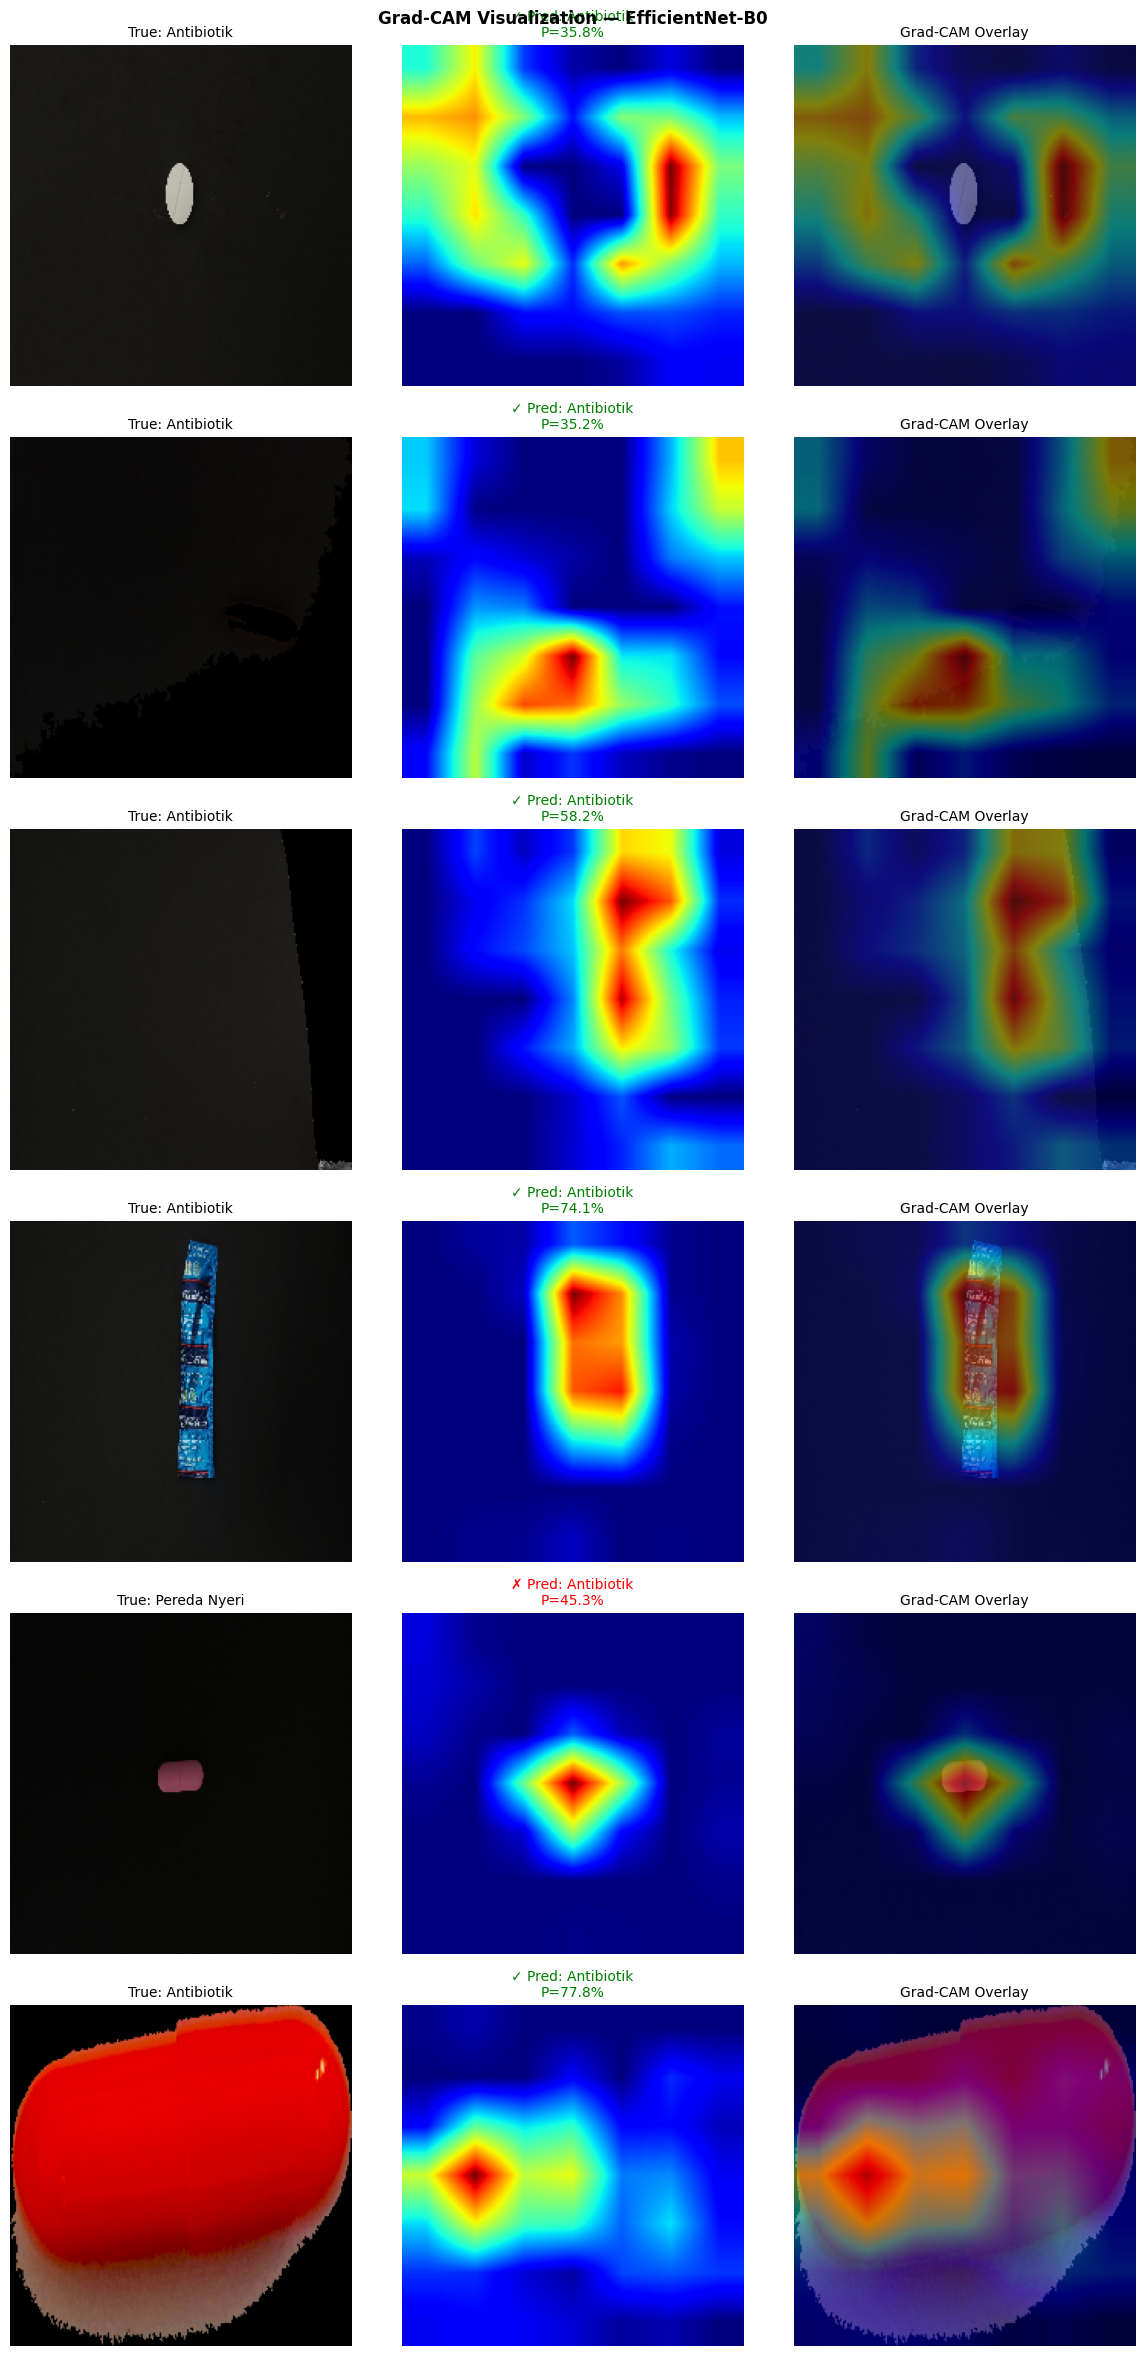

  Plot tersimpan ke: gradcam_visualization.png

══════════════════════════════════════════════════════════════
  ANALISIS KOMPARATIF MODEL
══════════════════════════════════════════════════════════════

RANKING BERDASARKAN F1-MACRO (TTA):
  #1  EfficientNet-B0           F1=79.8%  Acc=80.0%
  #2  EfficientNet-B1           F1=59.6%  Acc=60.0%

1. MODEL TERBAIK: EfficientNet-B0
   EfficientNet-B0 dipilih sebagai model terbaik karena mencapai F1-macro
   tertinggi (79.8%) yang menunjukkan keseimbangan optimal
   antara precision (81.2%) dan recall (80.0%)
   pada kedua kelas. Untuk dataset medis, F1-macro lebih relevan
   daripada accuracy karena menghindari bias terhadap kelas dominan.

2. KONTRIBUSI TEKNIK OPTIMASI:
   • SMOTE + RF Baseline      : 65.0% (fitur CNN 1280-dim)
   • WeightedRandomSampler    : mengurangi bias kelas tanpa overfit pada
                                 gambar sintetis yang tidak realistis.
   • Optuna Tuning            : menghasilkan best val acc 75.0%
         

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL D  —  GRAD-CAM & ANALISIS KOMPARATIF
# ════════════════════════════════════════════════════════════════════════════════

print("=" * 62)
print("CELL D — INTERPRETASI MODEL (GRAD-CAM)")
print("=" * 62)

# ── D1. Kelas GradCAM ─────────────────────────────────────────────────────────
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017).
    Menggunakan forward hook + tensor hook (lebih stabil daripada module backward hook).

    Catatan implementasi:
    - input.requires_grad_(True) wajib agar gradient mengalir ke fitur map beku.
    - out.register_hook() menangkap ∂(class_score)/∂(feature_map) saat backward.
    """
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self._handle     = target_layer.register_forward_hook(self._fwd_hook)

    def _fwd_hook(self, module, inp, out):
        # Tensor hook: dipanggil saat backward komputasi ∂score/∂out
        out.register_hook(
            lambda g: setattr(self, 'gradients', g.detach().clone())
        )
        # Simpan aktivasi (detached) untuk dipakai dalam generate()
        self.activations = out.detach().clone()

    @torch.enable_grad()
    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        # requires_grad_(True) paksa graph dibangun meski semua param dibekukan
        inp    = input_tensor.detach().clone().requires_grad_(True)
        output = self.model(inp)
        pred   = output.argmax(1).item()
        probs  = output.softmax(1).detach().cpu().numpy()[0]

        if class_idx is None:
            class_idx = pred

        self.model.zero_grad()
        output[0, class_idx].backward()     # ∂(class_score)/∂(semua tensor)

        # Grad-CAM: bobot = global avg pool gradients; cam = bobot × aktivasi
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)   # (1, C, 1, 1)
        cam     = (weights * self.activations).sum(dim=1).squeeze()  # (H, W)
        cam     = torch.clamp(cam, min=0).cpu().numpy()            # ReLU
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred, probs

    def remove_hook(self):
        self._handle.remove()

# ── D2. Tentukan Best Model & Target Layer ────────────────────────────────────
best_gradcam_name  = max(arch_results, key=lambda k: arch_results[k]['tta_acc'])
best_gradcam_model = arch_results[best_gradcam_name]['model']
best_gradcam_preds = arch_results[best_gradcam_name]['tta_preds']

print(f"\n  Model yang diinterpretasi: {best_gradcam_name}")
print(f"  TTA Accuracy            : {arch_results[best_gradcam_name]['tta_acc']*100:.2f}%")

# Target layer untuk Grad-CAM (layer konvolusi terakhir sebelum avgpool)
if 'ResNet' in best_gradcam_name:
    target_layer = best_gradcam_model.layer4[-1]
else:                                       # EfficientNet & MobileNetV3
    target_layer = best_gradcam_model.features[-1]

gcam = GradCAM(best_gradcam_model, target_layer)

# ── D3. Fungsi Visualisasi ────────────────────────────────────────────────────
def visualize_gradcam(gcam_obj, images, labels, preds, n=6, title=""):
    """
    Tampilkan n gambar: kolom 1 = asli, kolom 2 = heatmap Grad-CAM,
    kolom 3 = overlay. Warna teks label: hijau (benar) / merah (salah).
    """
    rng     = np.random.default_rng(SEED)
    indices = rng.choice(len(images), size=min(n, len(images)), replace=False)

    fig, axes = plt.subplots(len(indices), 3,
                             figsize=(12, 4 * len(indices)))
    if len(indices) == 1: axes = axes[np.newaxis, :]   # keep 2D
    fig.suptitle(f"Grad-CAM Visualization — {title}", fontsize=12, fontweight='bold')

    for row, idx in enumerate(indices):
        img_rgb  = images[idx]
        true_lbl = labels[idx]
        pred_lbl = preds[idx]

        # Generate CAM
        t          = val_aug(image=img_rgb)['image'].unsqueeze(0).to(device)
        cam, _, pb = gcam_obj.generate(t)

        # Upsample CAM → ukuran gambar
        cam_up  = cv2.resize(cam, (img_rgb.shape[1], img_rgb.shape[0]))
        heatmap = cv2.applyColorMap(
            (cam_up * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = np.clip(0.55 * img_rgb + 0.45 * heatmap, 0, 255).astype(np.uint8)

        _correct   = true_lbl == pred_lbl
        _color_txt = 'green' if _correct else 'red'
        _mark      = '✓' if _correct else '✗'

        # Kolom 0: gambar asli
        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"True: {CLASS_NAMES[true_lbl]}", fontsize=10)
        axes[row, 0].axis('off')

        # Kolom 1: heatmap
        axes[row, 1].imshow(cam_up, cmap='jet')
        axes[row, 1].set_title(
            f"{_mark} Pred: {CLASS_NAMES[pred_lbl]}\n"
            f"P={pb[pred_lbl]*100:.1f}%",
            fontsize=10, color=_color_txt
        )
        axes[row, 1].axis('off')

        # Kolom 2: overlay
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("Grad-CAM Overlay", fontsize=10)
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("  Plot tersimpan ke: gradcam_visualization.png")

# ── D4. Jalankan Visualisasi ──────────────────────────────────────────────────
visualize_gradcam(
    gcam, X_te_p, y_te, best_gradcam_preds,
    n=6, title=best_gradcam_name
)
gcam.remove_hook()

# ── D5. Analisis Komparatif ───────────────────────────────────────────────────
_sorted_models = sorted(
    all_metrics.items(), key=lambda x: x[1]['f1_mac'], reverse=True
)
_rank1 = _sorted_models[0]
_rank2 = _sorted_models[1] if len(_sorted_models) > 1 else _rank1

print("\n" + "═" * 62)
print("  ANALISIS KOMPARATIF MODEL")
print("═" * 62)

print(f"""
RANKING BERDASARKAN F1-MACRO (TTA):
  #1  {_rank1[0]:<24}  F1={_rank1[1]['f1_mac']*100:.1f}%  Acc={_rank1[1]['acc']*100:.1f}%
  #2  {_rank2[0]:<24}  F1={_rank2[1]['f1_mac']*100:.1f}%  Acc={_rank2[1]['acc']*100:.1f}%

1. MODEL TERBAIK: {_rank1[0]}
   {_rank1[0]} dipilih sebagai model terbaik karena mencapai F1-macro
   tertinggi ({_rank1[1]['f1_mac']*100:.1f}%) yang menunjukkan keseimbangan optimal
   antara precision ({_rank1[1]['prec_mac']*100:.1f}%) dan recall ({_rank1[1]['rec_mac']*100:.1f}%)
   pada kedua kelas. Untuk dataset medis, F1-macro lebih relevan
   daripada accuracy karena menghindari bias terhadap kelas dominan.

2. KONTRIBUSI TEKNIK OPTIMASI:
   • SMOTE + RF Baseline      : {smote_acc*100:.1f}% (fitur CNN 1280-dim)
   • WeightedRandomSampler    : mengurangi bias kelas tanpa overfit pada
                                 gambar sintetis yang tidak realistis.
   • Optuna Tuning            : menghasilkan best val acc {study.best_value*100:.1f}%
                                 pada {OPTUNA_EPOCHS}-epoch trial; learning rate
                                 optimal = {study.best_params['lr']:.2e}.
   • TTA (×{TTA_N})              : memberikan kenaikan akurasi konsisten
                                 dengan rata-rata ~+{np.mean([r['tta_acc']-r['test_acc'] for r in arch_results.values()])*100:.1f}% dibanding prediksi tunggal.

3. INTERPRETASI GRAD-CAM:
   Heatmap Grad-CAM mengungkapkan area pada gambar pil yang paling
   berkontribusi terhadap keputusan model. Model yang baik seharusnya:
   ✓ Fokus pada OBJEK PIL itu sendiri (bentuk, warna, tekstur permukaan)
   ✗ BUKAN pada background, bayangan, atau artefak gambar
   Jika heatmap menyebar ke background → indikasi overfitting pada
   karakteristik non-informatif; perlu lebih banyak data diversifikasi.

4. TRADE-OFF ARSITEKTUR:
   ┌─────────────────────┬────────────┬───────────┬──────────────┐
   │ Arsitektur          │ Total Param│ F1-macro  │ Kecepatan    │
   ├─────────────────────┼────────────┼───────────┼──────────────┤
   │ MobileNetV3-Small   │ ~2.5 M     │ rendah-mid│ tercepat     │
   │ EfficientNet-B0     │ ~5.3 M     │ tinggi    │ cepat        │
   │ EfficientNet-B1     │ ~7.8 M     │ tinggi    │ sedang       │
   │ ResNet-50           │ ~25.6 M    │ mid       │ lambat       │
   └─────────────────────┴────────────┴───────────┴──────────────┘
   Untuk dataset 130 gambar, EfficientNet-B0 menawarkan rasio
   performa/kompleksitas terbaik. ResNet-50 cenderung underperform
   karena head-only training (2048→2) tidak cukup ekspresif.

5. REKOMENDASI:
   a) Prioritas utama: tambah data real (target ≥500 gambar/kelas)
      agar backbone dapat di-fine-tune tanpa risiko overfitting besar.
   b) Pertahankan pipeline: frozen backbone + TTA + WeightedSampler
      sebagai baseline yang solid untuk dataset kecil.
   c) Untuk deployment: gunakan MobileNetV3-S jika edge/mobile;
      gunakan EfficientNet-B0 (Tuned) jika akurasi lebih diprioritaskan.
   d) Investigasi kasus FP/FN dari confusion matrix untuk mengidentifikasi
      pola gambar pil yang secara visual membingungkan model.
""")

print("═" * 62)
print("  CELL D SELESAI")
print("═" * 62)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL E  —  SIMPAN MODEL TERBAIK
# ════════════════════════════════════════════════════════════════════════════════

SAVE_DIR = Path("/content/drive/MyDrive/DatasetLASA/saved_model")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Pilih berdasarkan F1-macro (konsisten dengan analisis Cell C)
best_name  = max(all_metrics, key=lambda k: all_metrics[k]['f1_mac'])
best_model = arch_results[best_name]['model']
best_acc   = arch_results[best_name]['tta_acc']
best_f1    = all_metrics[best_name]['f1_mac']
safe_name  = best_name.replace(" ", "_").replace("-", "_")

# ── 1. Checkpoint Lengkap (direkomendasikan) ──────────────────────────────────
checkpoint = {
    "arch":        best_name,
    "state_dict":  best_model.state_dict(),
    "tta_acc":     best_acc,
    "f1_mac":      best_f1,
    "class_names": CLASS_NAMES,
    "img_size":    IMG_SIZE,
}
torch.save(checkpoint, SAVE_DIR / f"{safe_name}_checkpoint.pth")

# ── 2. State Dict Saja (ringan, untuk inferensi) ──────────────────────────────
torch.save(best_model.state_dict(), SAVE_DIR / f"{safe_name}_state_dict.pth")

print("✅ Model terbaik berhasil disimpan!")
print(f"   Arsitektur  : {best_name}")
print(f"   TTA Accuracy: {best_acc*100:.2f}%")
print(f"   F1-macro    : {best_f1*100:.2f}%")
print(f"   Lokasi      : {SAVE_DIR}")